# **Ensemble Modeling**

#### **Decision Trees and Random Forests**

In [45]:
# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns
import matplotlib.pyplot as plt



# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    RepeatedKFold
)

from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, root_mean_squared_error, accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score, recall_score
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LogisticRegression, Lasso, RidgeClassifier, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble        import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier, RUSBoostClassifier
# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

#### **Dataset Imports**

In [46]:
from pathlib import Path

print(Path.cwd())
print((Path.cwd() / "../NFL_Injury_Prediction/Datasets/Big-Data-Bowl/BDB_Experimental.csv").resolve())

/Users/leemcfarling/Projects/NFL_Injury_Prediction
/Users/leemcfarling/Projects/NFL_Injury_Prediction/Datasets/Big-Data-Bowl/BDB_Experimental.csv


In [47]:

BDB_All_Plays_Model_Ready = pd.read_csv("../NFL_Injury_Prediction/Datasets/Big-Data-Bowl/BDB_Experimental.csv") # Big Data Bowl Dataset


In [48]:
BDB_All_Plays_Model_Ready

,gameId,quarter,down,yardsToGo,yardlineNumber,preSnapHomeScore,preSnapVisitorScore,penaltyYards,prePenaltyPlayResult,playResult,...,pff_passCoverage_Cover-2,pff_passCoverage_Cover-3,pff_passCoverage_Cover-6,pff_passCoverage_Goal Line,pff_passCoverage_Miscellaneous,pff_passCoverage_Prevent,pff_passCoverage_Quarters,pff_passCoverage_Red Zone,pff_passCoverageType_Other,pff_passCoverageType_Zone
0,2021090900,1,3,2,33,0,0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2021090900,1,2,6,34,0,0,0.0,5,5,...,0,1,0,0,0,0,0,0,0,1
2,2021090900,1,1,10,39,0,0,0.0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,2021090900,1,3,15,44,0,0,0.0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,2021090900,1,2,5,11,0,0,0.0,10,10,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8544,2021110100,4,3,8,8,17,17,0.0,-8,-8,...,0,0,0,0,0,0,0,0,1,0
8545,2021110100,4,1,10,25,20,17,0.0,3,3,...,1,0,0,0,0,0,0,0,0,1
8546,2021110100,4,2,7,28,20,17,0.0,-8,-8,...,1,0,0,0,0,0,0,0,0,1
8547,2021110100,4,3,15,20,20,17,0.0,0,0,...,1,0,0,0,0,0,0,0,0,1


And let's set aside a copy of the column we are grouping on: 

In [49]:
BDB_groups = BDB_All_Plays_Model_Ready['gameId']


### **Useful Functions**

Once again, we will be using the train test split, the run_model_classifier, and the standardize features functions that we obtained originally from Module 3, and have since adapted in the weeks preceeding this. 

In [50]:
# ===========================================================================================
# Function taken from Module 3 Final Project
# https://github.com/LeeMcFarling/Final_Project_Writeup/blob/main/Final_Project_Report.ipynb
# ===========================================================================================

def train_test_split_data(df, target_col, groups_col=None):
    X = df.drop(columns=[c for c in [target_col, groups_col] if c])
    y = df[target_col]

    groups = df[groups_col] if groups_col else None

    # Stratify only if not using groups (can't do both)
    stratify = y if groups is None else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=stratify
    )

    if groups is not None:
        groups_train = groups.loc[X_train.index]
        groups_test  = groups.loc[X_test.index]
        return X_train, X_test, y_train, y_test, groups_train, groups_test

    return X_train, X_test, y_train, y_test

And train test split (the function is stratified automatically)

In [51]:
# BDB_All_Plays_Model_Ready = BDB_All_Plays_Model_Ready.drop(columns='gameId', axis=1)

In [52]:
(bdb_X_train, bdb_X_test, bdb_y_train, bdb_y_test,
 bdb_groups_train, bdb_groups_test) = train_test_split_data(
    BDB_All_Plays_Model_Ready,   # still has gameId in it
    target_col='Inj_Occured',
    groups_col='gameId'
)

## **Standardization Function**

In [53]:
# =============================================================================================
# Standardize Numeric Features
#
# Taken from Week 2.ipynb and modified to exclude the hard coded logic
#  
# Originally taken from Mod 3 final project found here: 
# https://github.com/LeeMcFarling/Final_Project_Writeup/blob/main/Final_Project_Report.ipynb
#
# =============================================================================================


def standardize_features(df, target_column=None, debug=False, return_scaler=False):
    df_scaled = df.copy()

    # 1) Automatically detect numeric columns
    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    # 2) Remove target if present
    if target_column in numeric_cols:
        numeric_cols.remove(target_column)

    # 3) Exclude binary (0/1) columns
    numeric_cols_to_scale = [
        col for col in numeric_cols
        if df[col].nunique(dropna=True) > 2
    ]

    if debug:
        print("Numeric columns before filtering:", numeric_cols)
        print("Numeric columns after filtering:", numeric_cols_to_scale)

    # 4) Apply StandardScaler
    scaler = StandardScaler()
    if numeric_cols_to_scale:
        df_scaled[numeric_cols_to_scale] = scaler.fit_transform(df_scaled[numeric_cols_to_scale])

    if return_scaler:
        return df_scaled, scaler, numeric_cols_to_scale
    return df_scaled

And using this scale our feature sets. 

In [54]:
bdb_X_train_scaled, scaler, scaled_cols = standardize_features(
    bdb_X_train, target_column=None, return_scaler=True
)

# applyin the same scaler
bdb_X_test_scaled = bdb_X_test.copy()
bdb_X_test_scaled[scaled_cols] = scaler.transform(bdb_X_test[scaled_cols])

## **Useful Functions: Parameter Sweeps**

In [55]:
def run_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    metric='recall',
    pos_label=1,
    **model_params
):
    metric_info = get_metric_functions(metric=metric, pos_label=pos_label)
    scoring_name = metric_info['scoring_name']
    metric_func = metric_info['metric_func']

    model_params = model_params.copy()
    for k in [
        'accuracy_found',
        'balanced_accuracy_found',
        'precision_found',
        'recall_found',
        'f1_found'
    ]:
        model_params.pop(k, None)

    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    cv = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=n_repeats,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring=scoring_name,
        cv=cv,
        n_jobs=n_jobs
    )

    mean_cv = np.mean(cv_scores)
    std_cv = np.std(cv_scores)

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_metric = metric_func(y_train, train_preds)
    test_metric = metric_func(y_test, test_preds)

    return mean_cv, std_cv, train_metric, test_metric

And we'll pair that with a resolver (purely so we can switch between different metrics like recall, F1, Accuracy, etc.)

In [56]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np


def get_metric_functions(metric='recall', pos_label=1):
    metric = metric.lower()

    metric_map = {
        'accuracy': {
            'scoring_name': 'accuracy',
            'metric_func': lambda y_true, y_pred: accuracy_score(y_true, y_pred),
            'metric_label': 'Accuracy',
            'metric_key': 'accuracy_found'
        },
        'balanced_accuracy': {
            'scoring_name': 'balanced_accuracy',
            'metric_func': lambda y_true, y_pred: balanced_accuracy_score(y_true, y_pred),
            'metric_label': 'Balanced Accuracy',
            'metric_key': 'balanced_accuracy_found'
        },
        'precision': {
            'scoring_name': 'precision',
            'metric_func': lambda y_true, y_pred: precision_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'Precision',
            'metric_key': 'precision_found'
        },
        'recall': {
            'scoring_name': 'recall',
            'metric_func': lambda y_true, y_pred: recall_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'Recall',
            'metric_key': 'recall_found'
        },
        'f1': {
            'scoring_name': 'f1',
            'metric_func': lambda y_true, y_pred: f1_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'F1',
            'metric_key': 'f1_found'
        }
    }

    if metric not in metric_map:
        raise ValueError(
            f"Unsupported metric '{metric}'. Choose from: {list(metric_map.keys())}"
        )

    return metric_map[metric]

And parameter Sweep Function: 

In [57]:
def sweep_parameter(
    model,
    Parameters,
    param,
    parameter_list,
    *,
    X_train,
    y_train,
    X_test,
    y_test,
    metric='recall',
    pos_label=1,
    verbose=True,
    n_iter_no_change=None,
    delta=0.001,
    n_jobs=-1,
    n_repeats=10,
):
    import time
    import numpy as np
    from tqdm import tqdm
    import matplotlib.pyplot as plt

    start = time.time()
    Parameters = Parameters.copy()

    metric_info = get_metric_functions(metric=metric, pos_label=pos_label)
    metric_label = metric_info['metric_label']
    metric_key = metric_info['metric_key']

    cv_metrics, std_cvs, train_metrics, test_metrics = [], [], [], []
    no_improve_count = 0
    best_metric = -np.inf

    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        P_temp = Parameters.copy()
        P_temp[param] = p

        # Remove any stored sweep bookkeeping keys
        for k in [
            'accuracy_found',
            'balanced_accuracy_found',
            'precision_found',
            'recall_found',
            'f1_found'
        ]:
            P_temp.pop(k, None)

        mean_cv, std_cv, train_metric, test_metric = run_model(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            metric=metric,
            pos_label=pos_label,
            **P_temp
        )

        cv_metrics.append(mean_cv)
        std_cvs.append(std_cv)
        train_metrics.append(train_metric)
        test_metrics.append(test_metric)

        if mean_cv > best_metric + delta:
            best_metric = mean_cv
            no_improve_count = 0
        else:
            no_improve_count += 1

        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            if verbose:
                print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    max_cv_metric = max(cv_metrics)
    max_index = cv_metrics.index(max_cv_metric)
    best_param = parameter_list[max_index]

    Parameters[param] = best_param
    Parameters[metric_key] = max_cv_metric

    if verbose:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

        partial_param_list = parameter_list[:len(cv_metrics)]

        # Use index positions for non-numeric / mixed values
        use_index_axis = not all(
            isinstance(v, (int, float, bool, np.integer, np.floating)) or v is None
            for v in partial_param_list
        )

        if use_index_axis:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(v) for v in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = [str(v) for v in partial_param_list]

        ax1.set_title(f"{metric_label} vs {param}")
        ax1.plot(x_vals, cv_metrics, marker='.', label=f"CV {metric_label}")
        ax1.plot(x_vals, train_metrics, marker='.', label=f"Train {metric_label}")
        ax1.plot(x_vals, test_metrics, linestyle='--', label=f"Test {metric_label}")
        ax1.scatter([x_vals[max_index]], [max_cv_metric], marker='x', label="Best CV")
        ax1.set_ylabel(metric_label)
        ax1.legend()
        ax1.grid()

        ax2.set_title(f"CV Std vs {param}")
        ax2.plot(x_vals, std_cvs, marker='.', label="CV Std")
        ax2.set_xlabel(param)
        ax2.set_ylabel("Std")
        ax2.legend()
        ax2.grid(alpha=0.5)

        if use_index_axis:
            ax1.set_xticks(x_vals)
            ax1.set_xticklabels(x_labels, rotation=45, ha='right')
            ax2.set_xticks(x_vals)
            ax2.set_xticklabels(x_labels, rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters

## **Trained Model Cross Validation Runs**

In [58]:
def run_model_classifier(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    run_comment=None,
    return_model=False,
    concat_results=False,
    recall_pos_label=1,
    **model_params
):

    global combined_results

    # Remove extra key used to store error metric, if it was added to the parameter dictionary
    if 'accuracy_found' in model_params:
        model_params = model_params.copy()
        model_params.pop('accuracy_found', None)

    # Instantiate the model if a class is provided
    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    model_name = model.__name__ if isinstance(model, type) else model.__class__.__name__

    # Use RepeatedStratifiedKFold for classification to preserve class distribution
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=42)

    # Cross-validation scores
    cv_accuracy_scores = cross_val_score(
        model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=n_jobs
    )
    cv_balanced_accuracy_scores = cross_val_score(
        model, X_train, y_train, scoring='balanced_accuracy', cv=cv, n_jobs=n_jobs
    )
    cv_recall_scores = cross_val_score(
        model, X_train, y_train, scoring='recall', cv=cv, n_jobs=n_jobs
    )

    mean_cv_accuracy = np.mean(cv_accuracy_scores)
    std_cv_accuracy = np.std(cv_accuracy_scores)

    mean_cv_balanced_accuracy = np.mean(cv_balanced_accuracy_scores)
    std_cv_balanced_accuracy = np.std(cv_balanced_accuracy_scores)

    mean_cv_recall = np.mean(cv_recall_scores)
    std_cv_recall = np.std(cv_recall_scores)

    # Fit the model on the full training set
    model.fit(X_train, y_train)

    # Compute predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # Standard Accuracy
    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)

    # Balanced Accuracy
    balanced_train_accuracy = balanced_accuracy_score(y_train, train_preds)
    balanced_test_accuracy = balanced_accuracy_score(y_test, test_preds)

    # Recall for injury / positive class
    train_recall = recall_score(y_train, train_preds, pos_label=recall_pos_label, zero_division=0)
    test_recall = recall_score(y_test, test_preds, pos_label=recall_pos_label, zero_division=0)

    results_df = pd.DataFrame([{
        'model': model_name,
        'model_params': model.get_params(),
        'mean_cv_accuracy': mean_cv_accuracy,
        'std_cv_accuracy': std_cv_accuracy,
        'mean_cv_balanced_accuracy': mean_cv_balanced_accuracy,
        'std_cv_balanced_accuracy': std_cv_balanced_accuracy,
        'mean_cv_recall': mean_cv_recall,
        'std_cv_recall': std_cv_recall,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'balanced_train_accuracy': balanced_train_accuracy,
        'balanced_test_accuracy': balanced_test_accuracy,
        'train_recall': train_recall,
        'test_recall': test_recall,
        'run_comment': run_comment
    }])

    if concat_results:
        try:
            combined_results = pd.concat([combined_results, results_df], ignore_index=True)
        except NameError:
            combined_results = results_df

    return (results_df, model) if return_model else results_df

# **Decision Trees**

#### **Which DecisionTree parameters are most important?**

When first exploring  a complex model such as decision trees, it’s best to focus first on those parameters that most directly affect the shape of the tree and the method used for splitting nodes. Some parameters are more important than others, especially when first using a model. Here is an approximate ordering of the parameters from most significant to least. We will only experiment with the first 4 of these parameters in this homework. 

---

1. **max_depth** (default: **None**)  
   *Controls the maximum depth of the tree, which is crucial for managing overfitting and overall model complexity.*

2. **max_leaf_nodes** (default: **None**)  
   *An alternative to max_depth, this limits the number of leaf nodes and can be used to control tree size in a different way.*

3. **max_features** (default: **None**)  
   *Determines the maximum number of features considered when looking for the best split. Tuning this can affect the bias-variance trade-off.*

4. **min_samples_split** (default: **2**)  
   *Specifies the minimum number of samples required to split an internal node. It influences how “greedy” the tree is in creating splits.*

---

#### **For class imbalance**

5. **class_weight** (default: None**)
   *This is critically important for our class imbalance. It effectively tells our model that missing an injury is X times more important than misclassifying a normal play*

6. **min_samples_leaf** 
   *This is critical for extremely rare events. Basically makes sure that we have more samples per leaf to make sure we don't have one sample in a leaf that dominates a decision*

7. **Criterion**
   *Experiment with log loss to see how it*

And just make sure we have the correct model imported.

In [59]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'random_state': 42
}

Let's test the class imbalance first. 

Sweeping class_weight: 100%|██████████| 6/6 [00:03<00:00,  1.73it/s]


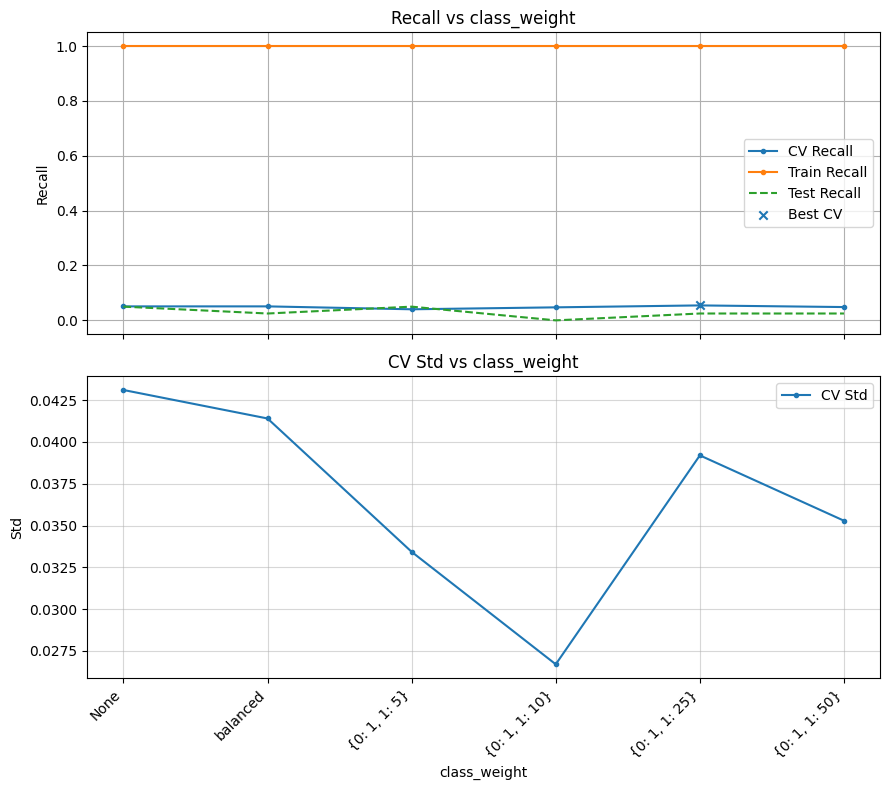

Execution Time: 00:00:03


Sweeping min_samples_leaf: 100%|██████████| 6/6 [00:01<00:00,  3.54it/s]


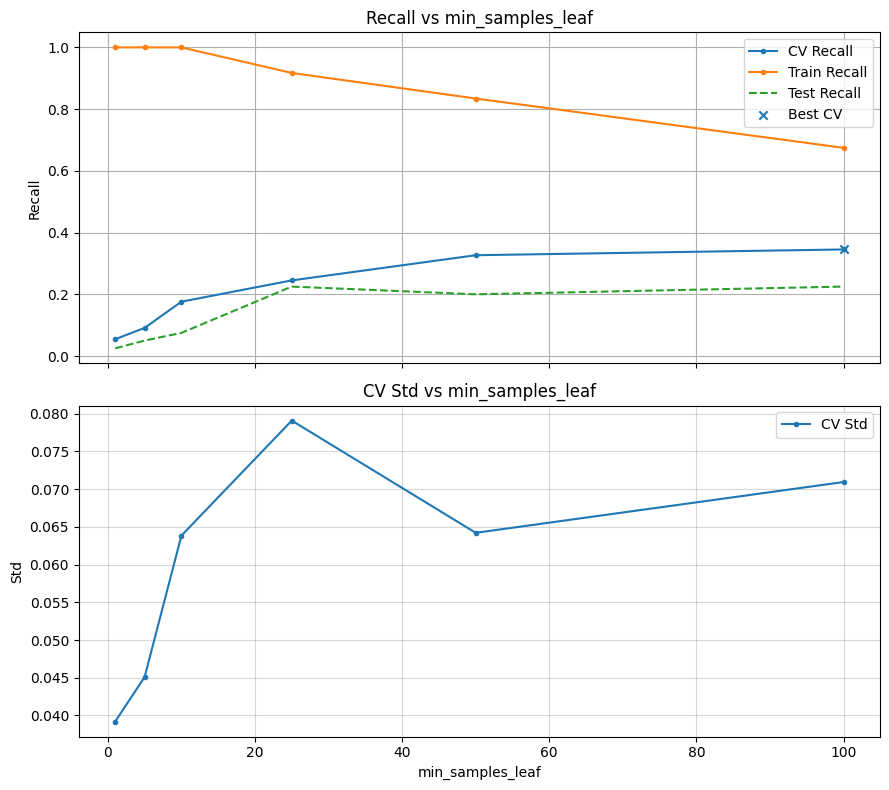

Execution Time: 00:00:01


Sweeping max_depth: 100%|██████████| 14/14 [00:03<00:00,  4.19it/s]


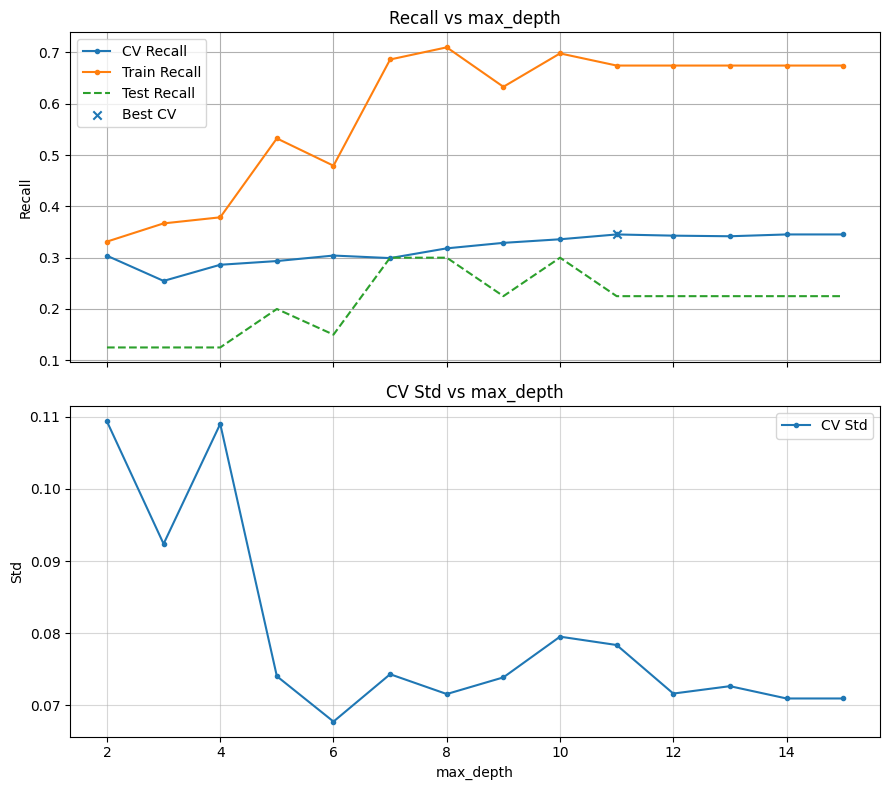

Execution Time: 00:00:03


Sweeping max_leaf_nodes: 100%|██████████| 7/7 [00:01<00:00,  3.94it/s]


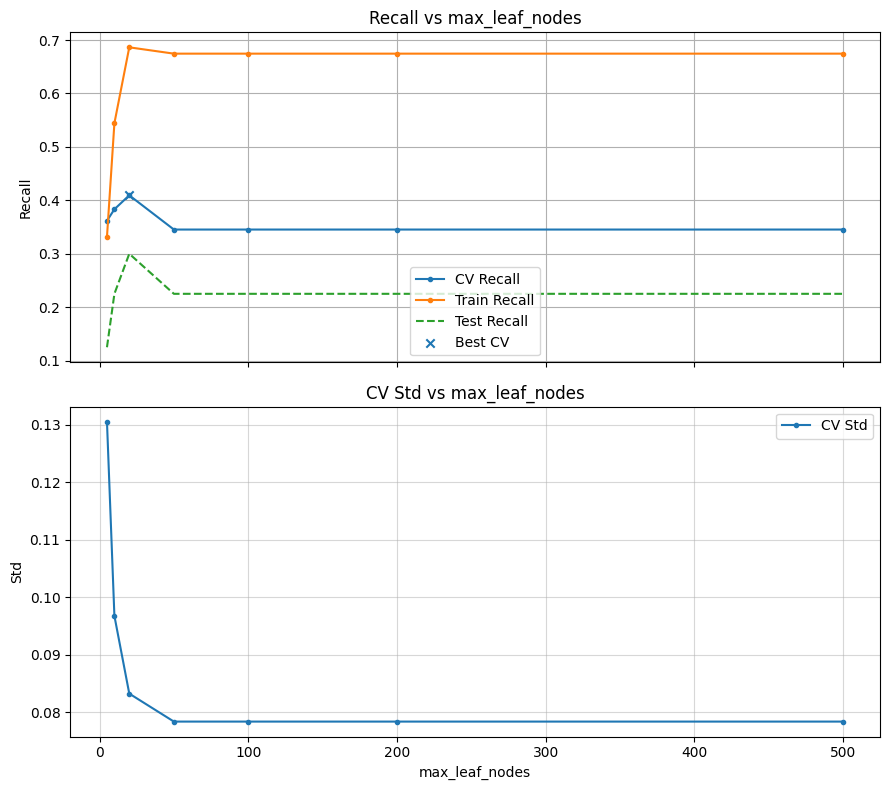

Execution Time: 00:00:01


Sweeping min_samples_split: 100%|██████████| 6/6 [00:01<00:00,  4.04it/s]


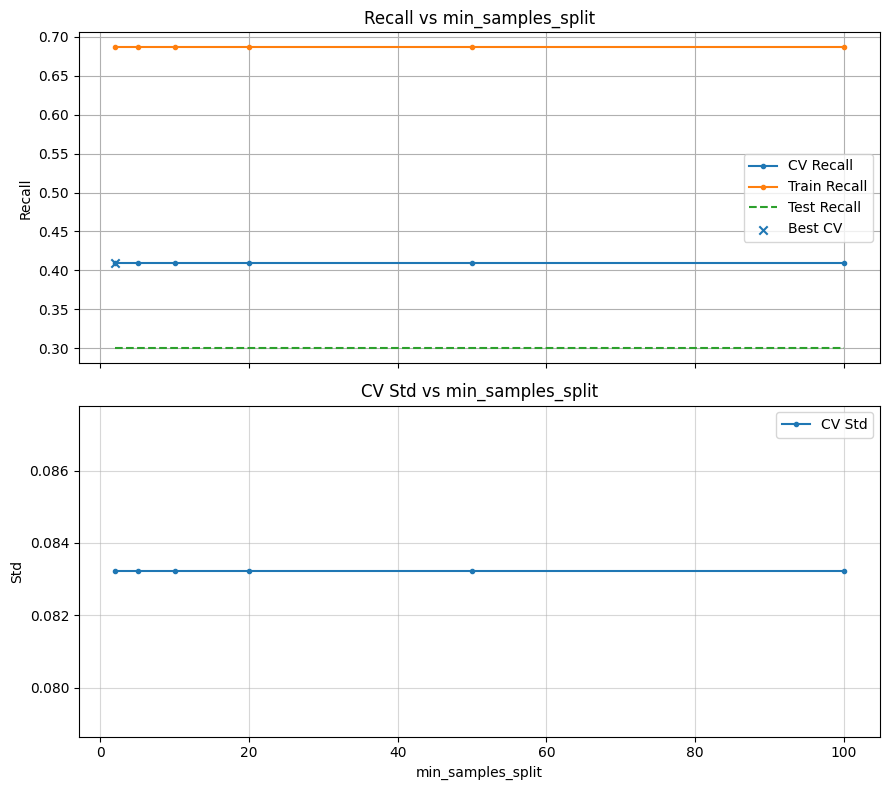

Execution Time: 00:00:01


Sweeping max_features: 100%|██████████| 6/6 [00:01<00:00,  4.87it/s]


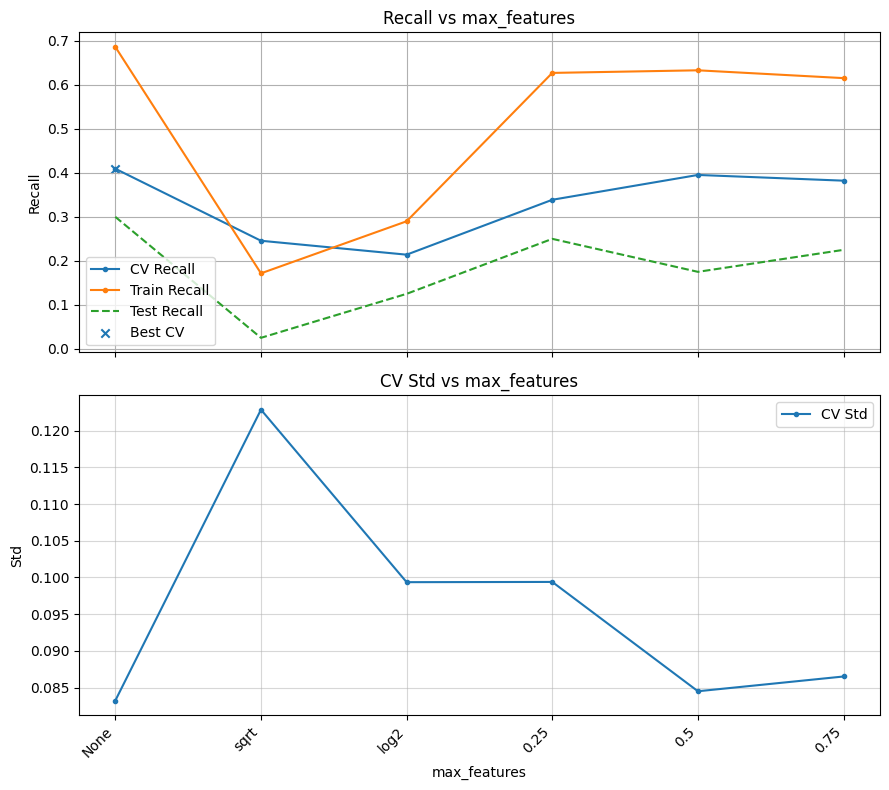

Execution Time: 00:00:01


Sweeping criterion: 100%|██████████| 3/3 [00:00<00:00,  4.80it/s]


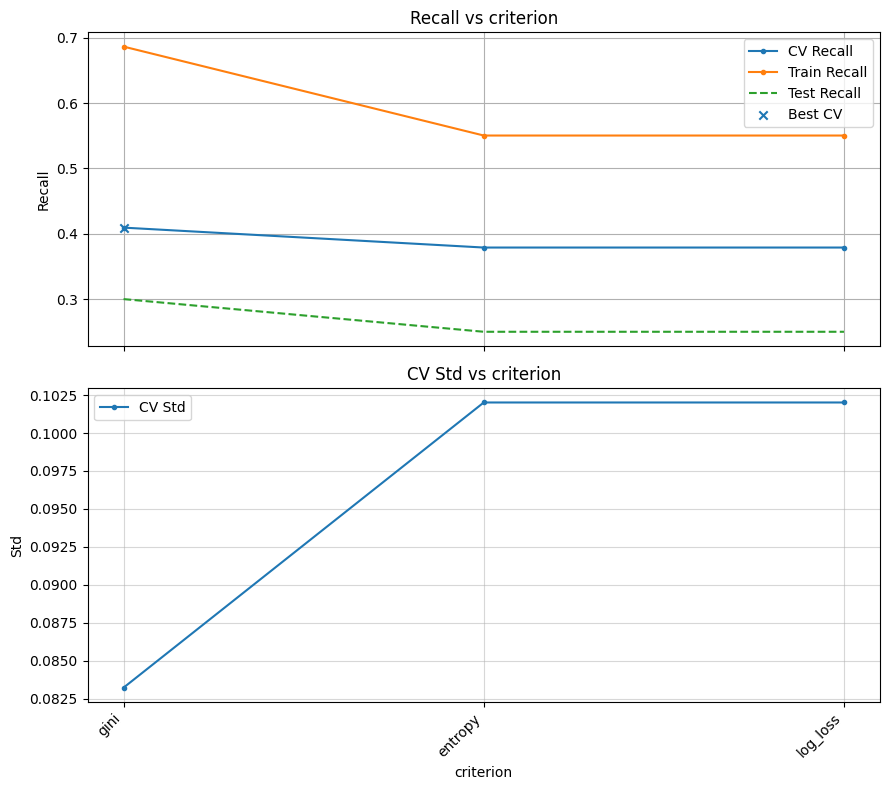

Execution Time: 00:00:00


{'random_state': 42,
 'class_weight': {0: 1, 1: 25},
 'recall_found': 0.4093761140819964,
 'min_samples_leaf': 100,
 'max_depth': 11,
 'max_leaf_nodes': 20,
 'min_samples_split': 2,
 'max_features': None,
 'criterion': 'gini'}

In [60]:
# 1. Class imbalance first: tell the tree injuries matter
dt_params = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params,
    param='class_weight',
    parameter_list=[
        None,
        'balanced',
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 25},
        {0: 1, 1: 50}
    ],
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    n_repeats=5,
    n_jobs=-1,
)

# 2. Prevent tiny leaves from memorizing rare injuries
dt_params = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params,
    param='min_samples_leaf',
    parameter_list=[1, 5, 10, 25, 50, 100],
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    n_repeats=5,
    n_jobs=-1,
)

# 3. Now control global tree complexity
dt_params = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params,
    param='max_depth',
    parameter_list=list(range(2, 16)),
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    n_repeats=5,
    n_jobs=-1,
)

# 4. Alternative complexity cap
dt_params = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params,
    param='max_leaf_nodes',
    parameter_list=[5, 10, 20, 50, 100, 200, 500],
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    n_repeats=5,
    n_jobs=-1,
)

# 5. Split greediness
dt_params = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params,
    param='min_samples_split',
    parameter_list=[2, 5, 10, 20, 50, 100],
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    n_repeats=5,
    n_jobs=-1,
)

# 6. Feature subsampling
dt_params = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params,
    param='max_features',
    parameter_list=[None, 'sqrt', 'log2', 0.25, 0.5, 0.75],
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    n_repeats=5,
    n_jobs=-1,
)

# 7. Criterion last: minor refinement
dt_params = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params,
    param='criterion',
    parameter_list=['gini', 'entropy', 'log_loss'],
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    n_repeats=5,
    n_jobs=-1,
)

dt_params

#### **Decision Tree Parameter Sweep Interpretations:**

From the plots, we can see that the *training* recall can easily go pretty high but the Cross validation recall only really gets better when we constrain our structure and conrol for the class imbalance. 

**Class Weight** for this one we can see that the decision tree can always memorize the factors that lead to injuries in the training set, but the cross validation barely moved throughout the exercise. 

While this was an interesting avenue for us to go down, it tells us that changing the class weighting isn't some magic secret that will unlock our ability to predict the injury class. We can chase it more aggressively by increasing the class weight more and more, but it will only result in a slight gain (and maybe a slight increase in variance too.)

**Min Samples Leaf** For this one, the Cross validation recall gained as we increased the minimum number of samples needed per leaf, and the training recall decreased as well (implying that there is less memorization of the training set). 

**^From our featurespace, there are things that broadly increase injury occurance, (broad groups in broad leaf structure)** BUT recall didn't go above like 30-40% no matter what we did, meaning that there is a strict limit to how much we could do (with one decision tree at least).

**Max Depth Plot** Both the training and CV recall go up in this instance, and the standard deviation goes down. This is majorly stabilizing as the amount of splits for each classification decision goes up to 14. 

Interestingly, this combined with the min samples per leaf means that broad groupings are more stable, but we would also need to combine many different factors as well. 


**Max leaf nodes** Basically stabilizes after 10 ish. This means the tree only needs 10 ish terminal regions and anything above that is just excess capacity. This can be interpreted as: There are a handful of broadly important trends in the data, but other than that not really. 


**Min samples split** Basically flat. Doesn't really effect fit here. 

**Max Features Plot** CV recall is highest at None, but the test recall was higher at 0.25 / 0.5. At 'None' the tree is basically using all features at each split and then choosing which one is the best. Sqrt means that it's the sqare root of the feature space (100 features = 10 features sampled at each split, next node, 10 new random features) so each decision is more constrained. 

log 2 is even more constrained than sqrt, and the 0.25 and 0.5 means sample from 1/4 or 1/2 of the features. This means that if we allow the tree to use all the features for each split, it goes after it aggressively, but it has a tendency to overfit. 

So we might be better off with sampling and ensemble methods here. 


The best decision tree params: 

In [61]:
best_dt_params = {
    'random_state': 42,
    'class_weight': {0: 1, 1: 25},
    'min_samples_leaf': 100,
    'max_depth': 14,
    'max_leaf_nodes': 10,
    'min_samples_split': 2,
    'max_features': None,
    'criterion': 'gini'
}

#### **BDB Decision Tree Final Run**

In [62]:
results_df, trained_dt = run_model_classifier(
    model=DecisionTreeClassifier,
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    return_model=True,
    concat_results=True,
    run_comment="Final tuned Decision Tree",
    **best_dt_params
)

results_df

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.73942,0.073812,0.550876,0.036933,0.352531,0.105049,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,Final tuned Decision Tree


Interesting, so the tuned decision tree had a CV recall of about 30% which is what we expected after inspecting the tuning graphs. But train recall was low meaning that the tree could assign injury / no injury broadly but was not memorizing individual cases (we did a good job in tuning). Test recall was brutal which means that out of the 20-40 positive cases in the test set, the model only got a couple. 

This was surprising but when the CV standard deviation across folds was considered, there was a high varaince (~14%) which I'm broadly interpreting as a signal that a single decision tree isn't the best for this exercise. Strong evidence that an ensemble model would be good here. 

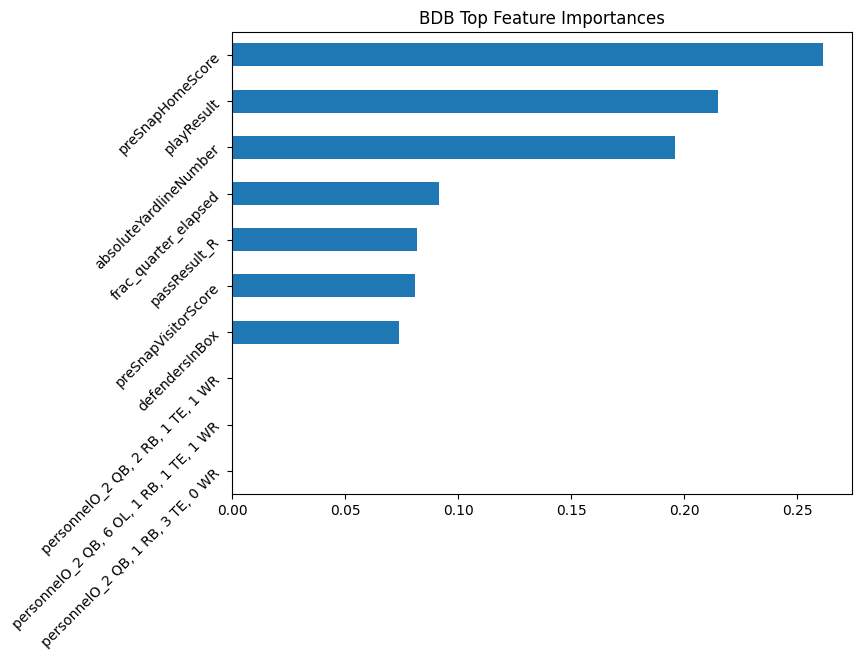

In [63]:
# DT Feature importances
feature_importances = pd.Series(
    trained_dt.feature_importances_,
    index=bdb_X_train_scaled.columns
).sort_values(ascending=False)

feature_importances.head(20)


# and plot ;)
feature_importances.head(10).sort_values().plot(
    kind='barh',
    figsize=(8,6),
    title='BDB Top Feature Importances'
)
plt.yticks(rotation=45)
plt.show()

___

# **BDB Random Forests**

First, let's optimize our parameters for rare-events based on our decision tree family. 

In [64]:
RF_SWEEP_DICT = {
    'n_estimators': [100, 250, 500], # Variance reduction 
    'class_weight': [ None, 'balanced', {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:25} ], # Rare even optimization
    'min_samples_leaf': [1, 5, 20, 50, 100],  # broader leaf structures (from DT observations)
    'max_features': ['sqrt', 'log2',  0.25,  0.5,  None], # regularization per leaf
    'max_depth': [ 5, 10, 15, None], # how many features decide injury 
}

rf_params = {
    'random_state': 42,
    'bootstrap': True
    # 'n_jobs': -1
}

This is not a typical random forest tuning strategy. It goes off of our DT from earlier ^

Sweeping n_estimators: 100%|██████████| 3/3 [00:11<00:00,  3.77s/it]


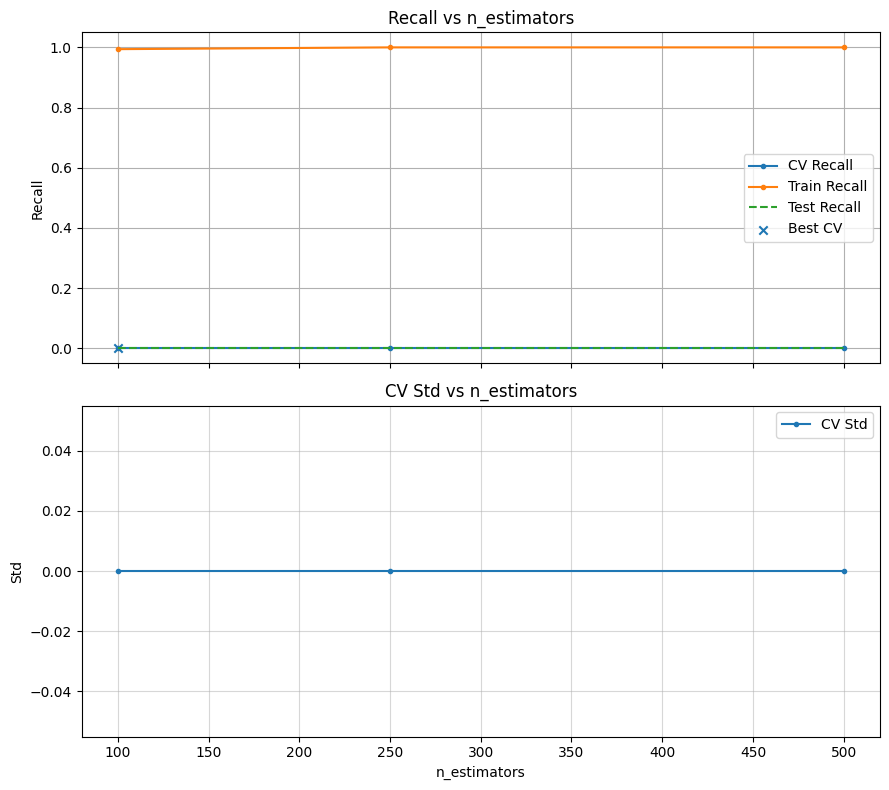

Execution Time: 00:00:11


Sweeping class_weight: 100%|██████████| 5/5 [00:07<00:00,  1.45s/it]


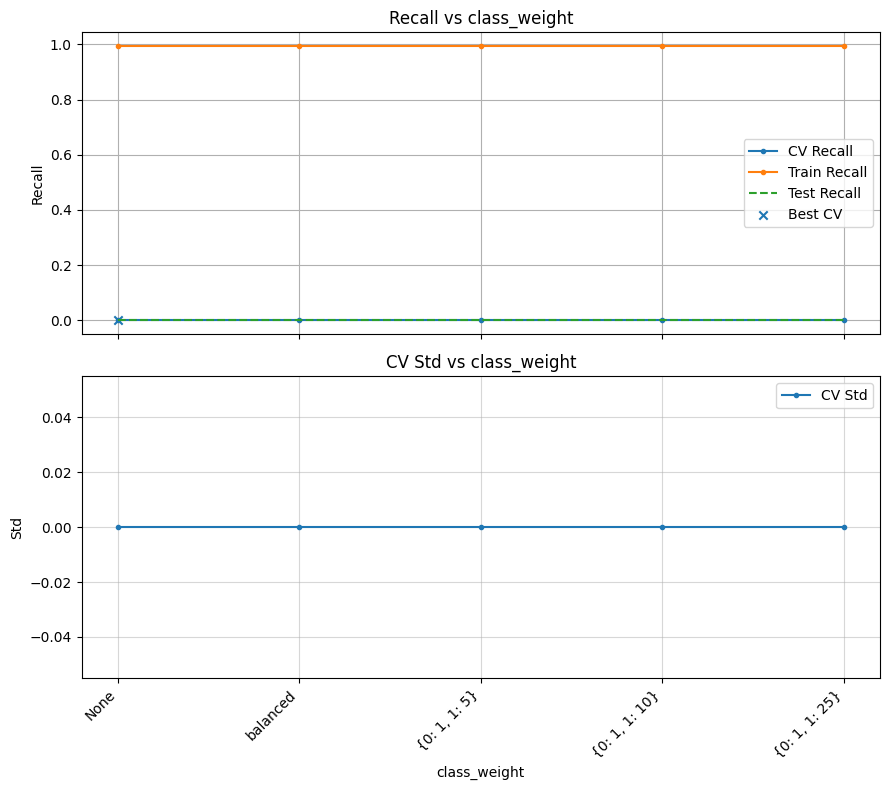

Execution Time: 00:00:07


Sweeping min_samples_leaf: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


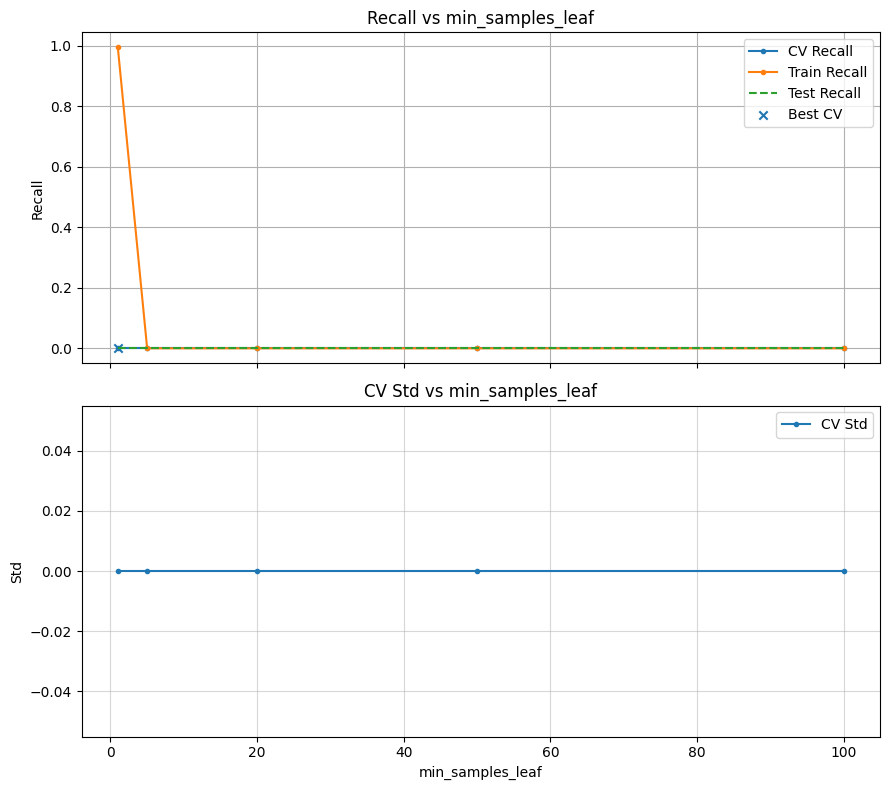

Execution Time: 00:00:05


Sweeping max_features: 100%|██████████| 5/5 [00:25<00:00,  5.04s/it]


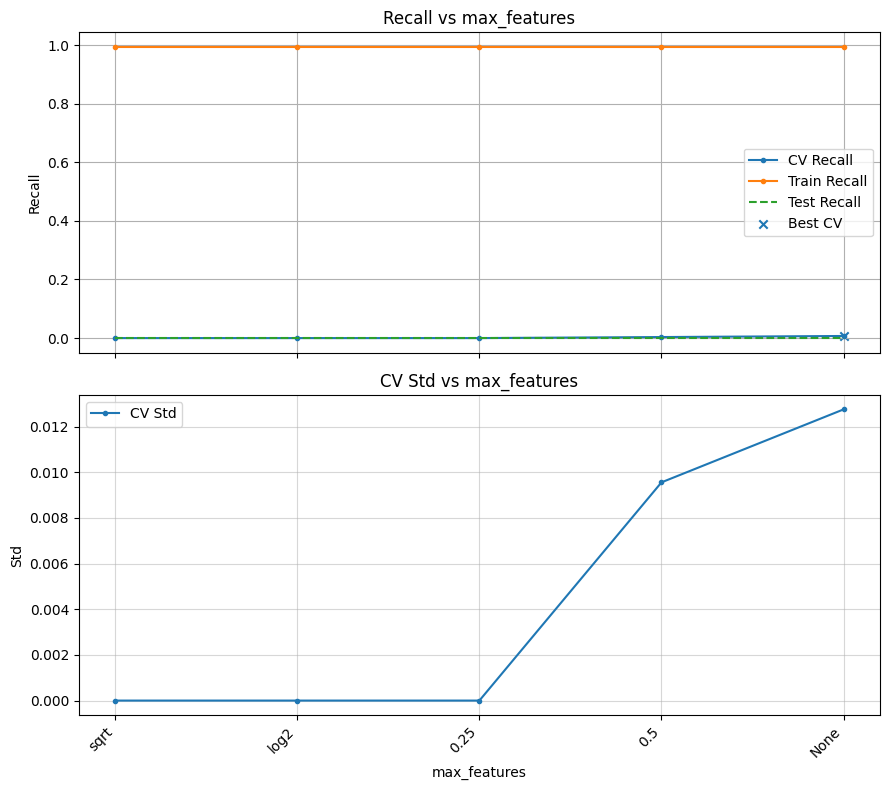

Execution Time: 00:00:25


Sweeping max_depth: 100%|██████████| 4/4 [00:33<00:00,  8.39s/it]


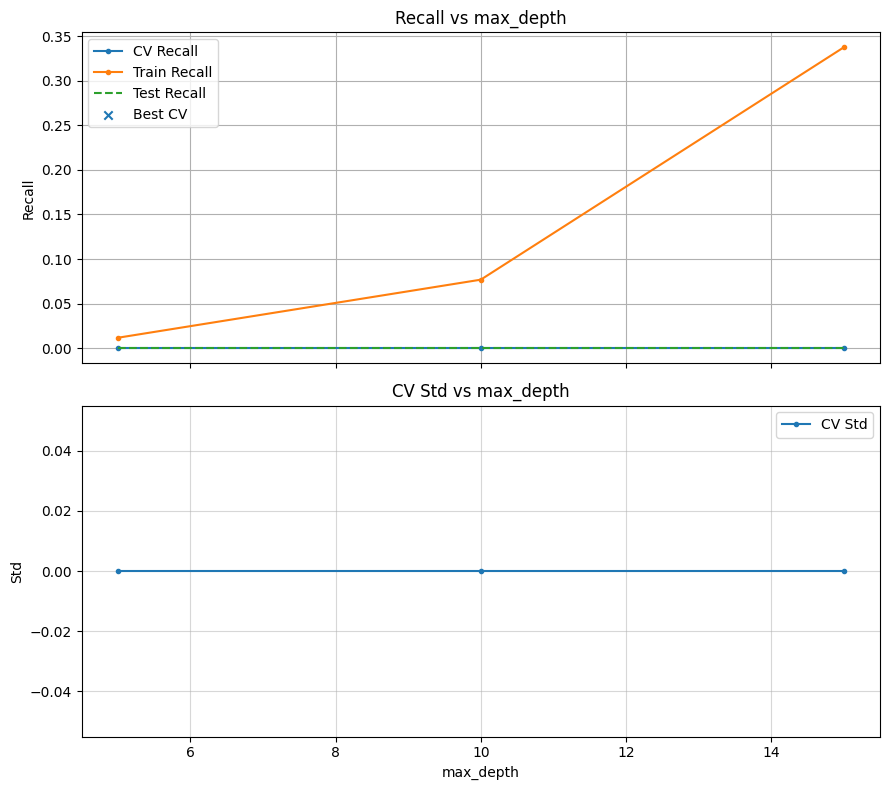

Execution Time: 00:00:33


{'random_state': 42,
 'bootstrap': True,
 'n_estimators': 100,
 'recall_found': 0.007165775401069519,
 'class_weight': None,
 'min_samples_leaf': 1,
 'max_features': None,
 'max_depth': None}

In [65]:
from sklearn.ensemble import RandomForestClassifier

for param, values in RF_SWEEP_DICT.items():

    rf_params = sweep_parameter(
        model=RandomForestClassifier,
        Parameters=rf_params,
        param=param,
        parameter_list=values,
        X_train=bdb_X_train_scaled,
        y_train=bdb_y_train,
        X_test=bdb_X_test_scaled,
        y_test=bdb_y_test,
        metric='recall',
        n_repeats=5,
        # n_jobs=-1
    )

rf_params

Brutal :( - Random forest essentially is way too conservative and is picking no injury every time. Rather than showing moderate recall with instability the RF just collapsed to zero recall across Cross validation. 

While ensembling reduced variance, it also made the model too conservative under the default classification rule. Likely because an RF takes an average of many decision trees, even if a decision tree is likely able to be tuned to pick the rare event (even if it produces more false positives), it still might not get that every time, and so that weak signal gets drowned on the ensemble architechture. So: 

tree 1 - Injury 
tree 2 - no injury 
tree 3 - no injury 
.
.
.
tree 100 - no injury 


RF concludes: no injury. 

Let's do a final run just to cross our t's and dot our i's.

In [66]:
best_rf_params = {
    'random_state': 42,
    'bootstrap': True,
    'n_estimators': 100,
    'class_weight': None,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'max_depth': 5
}

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf_results_df, trained_rf = run_model_classifier(
    model=RandomForestClassifier,
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    return_model=True,
    concat_results=True,
    run_comment="Final tuned Random Forest",
    **best_rf_params
)

rf_results_df

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.975289,0.000285,0.5,0.0,0.0,0.0,0.975289,0.976608,0.5,0.5,0.0,0.0,Final tuned Random Forest


And let's look at the test predictions just to be sure: 

In [68]:
import numpy as np

rf_test_preds = trained_rf.predict(bdb_X_test_scaled)

np.unique(rf_test_preds, return_counts=True)

(array([0]), array([1710]))

Yep, it's essentially predicted no injury every time. 

#### **RF Conlusions**

This produced a different failure mode from the single tree, rather than an unstable recall (from our high CV STD on the single tree), it produced predictions that basically collapsed to predicting no injury every time. This means that even though a single tree can predict broadly an injury, The majority voting  diluted the weak minority-class signal present in the dataset.

___

#### **Bagging Trees** 


So the typical random forest basically collapsed on the majoriy class, this could be from two reasons. Either A, the single decision tree could predict the 'injury' class but it does so in an unstable manor. Over many trees, the signal collapses to no injury because that happens in the majority of cases. 


OR 


The signal is just too weak. Because there is >97% chance of no injury, it just picks no injury, even if we try to get it to predict the non-majority class. 

In using bagging trees will remove feature subsampling and see if that balances the collapse from the normal random forest.

In [69]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

We won't be using our best decision tree from earlier, in general here, we want something that is more unstable, more prone to picking Injury, and then the bagging ensemble will stabilize that. So in general we want a tree that is has a high depth, a high class weight, and high min samples per leaf. 

In [70]:
base_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=10,
    class_weight={0:1,1:25},
    random_state=42
)

And then from there (this is mainly an experiment to see if wholistically if bagging across the whole decision space will stabilize it.)

In [71]:
bag_sweep_dict = {
    'n_estimators': [100, 200, 400], # how many trees
    'max_samples': [1.0, 0.7, 0.5], # diversity control 
    'max_features': [1.0, 0.7] 
}

Sweeping n_estimators: 100%|██████████| 3/3 [00:39<00:00, 13.04s/it]


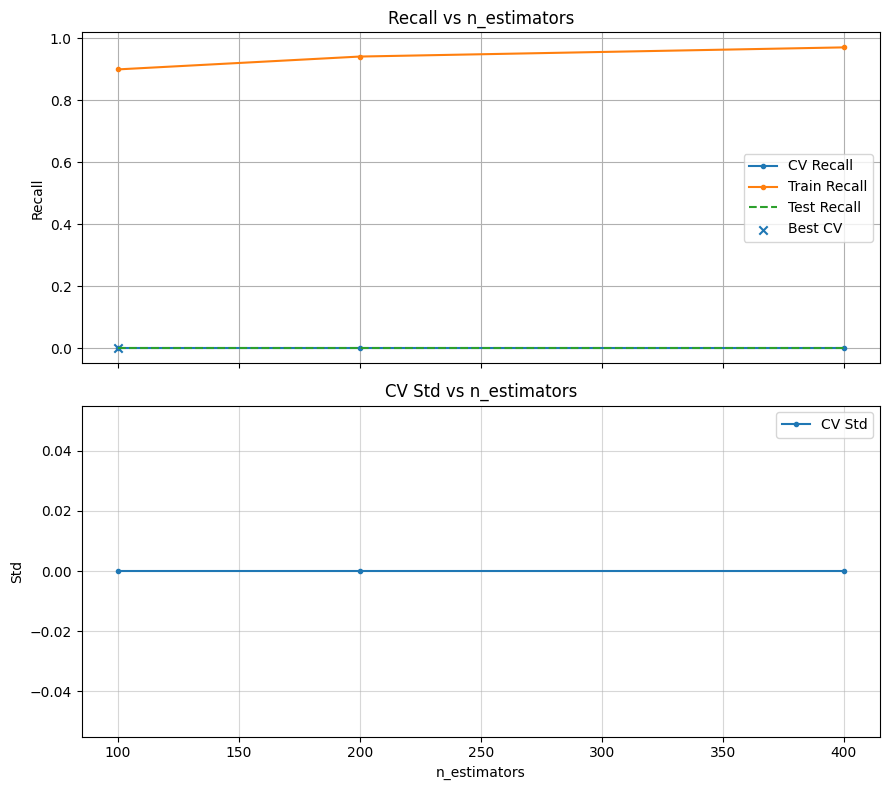

Execution Time: 00:00:39


Sweeping max_samples: 100%|██████████| 3/3 [00:14<00:00,  4.98s/it]


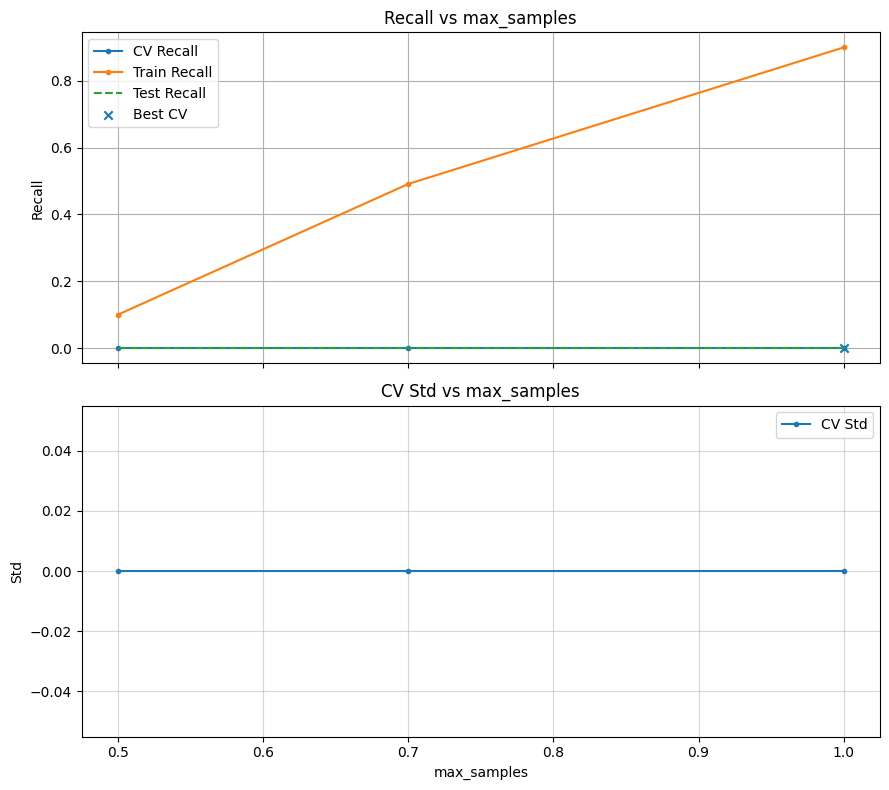

Execution Time: 00:00:15


Sweeping max_features: 100%|██████████| 2/2 [00:10<00:00,  5.36s/it]


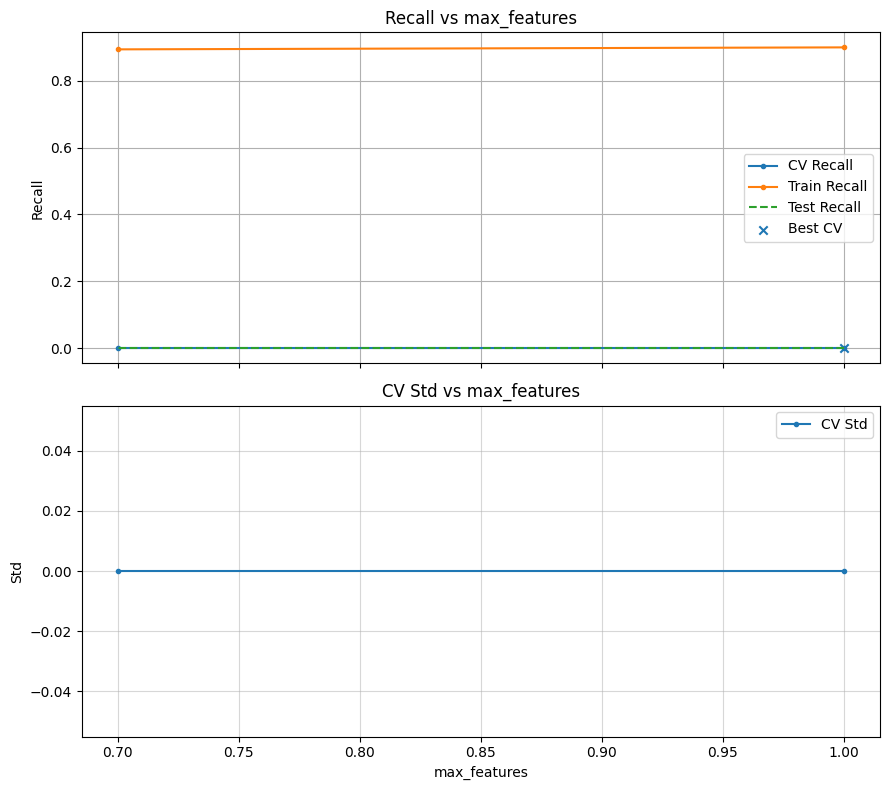

Execution Time: 00:00:10


{'random_state': 42,
 'n_estimators': 100,
 'recall_found': 0.0,
 'max_samples': 1.0,
 'max_features': 1.0}

In [72]:
bag_params = {'random_state': 42}

for param, values in bag_sweep_dict.items():

    bag_params = sweep_parameter(
        model=BaggingClassifier(
            estimator=base_tree,
            bootstrap=True,
            n_jobs=-1
        ),
        Parameters=bag_params,
        param=param,
        parameter_list=values,
        X_train=bdb_X_train_scaled,
        y_train=bdb_y_train,
        X_test=bdb_X_test_scaled,
        y_test=bdb_y_test,
        metric='recall',
        n_repeats=5
    )

bag_params

Yeah, so it's just collapsing on the majority class again. Because a single tree can predict, but the signal is reallly weak. In the RF parallel averaging overwhelms the rare-event detection here and so the model collapses to just predicting no injury every time. And now our example with Bagging Trees tells us that it's not the feature subsampling, it's the structure of the RF itself. 

Basically, unless many of our 100 + estimators all pick injury, the signal is going to say 'no-injury', which will collapse our minority recall. 

Because of this, we do our hard pivot into Boosting Methods because they **work sequentially** instead of trying to average across many parallel trees. This with the emphasis on injury recall will hopefully work to stabilize over time, and train the model to focus more on events that lead to injuries.  

Just for recording this, we'll do the final run_model_classifier. 

In [73]:
best_bag_params = {
    'random_state': 42,
    'n_estimators': 100,
    'max_samples': 1.0,
    'max_features': 1.0
}

In [74]:

bag_model_final = BaggingClassifier(
    estimator=base_tree,
    bootstrap=True,
    n_jobs=-1,
    **best_bag_params
)

In [75]:
bag_results_df, trained_bag = run_model_classifier(
    model=bag_model_final,
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    return_model=True,
    concat_results=True,
    run_comment="Final Bagging Trees (Collapsed Recall)"
)

bag_results_df

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,BaggingClassifier,"{'bootstrap': True, 'bootstrap_features': Fals...",0.974762,0.000746,0.49973,0.000344,0.0,0.0,0.997222,0.976608,0.949554,0.5,0.899408,0.0,Final Bagging Trees (Collapsed Recall)


Let's run a diagnostic and see how many times the bagging model predicted injuries here. 

In [76]:
np.unique(trained_bag.predict(bdb_X_test_scaled), return_counts=True)

(array([0]), array([1710]))

Interesting, so it's not a total collapse after all, but the training accuracy on certain folds is not replicating to other folds or the test set. Minority trees themselves can memorize the patterns but the ensemble. 


Even though the single DT from earlier was able to identify broad risks (the large leaf size) these still had a low injury prevalence overall. So even when a single tree correctly produced a signal, it was still destroyed across the parallel ensemble (15 / 1200 times = weak signal destroyed)

___

# **Gradient Boosted Classifier**

Ok so for this, we are trying to start with many shallow trees, with a controled learning rate so hopefully we can accumulate a minority signal. 

Here, our goal in the sweeps is to start off with a crude approximation, and then have the model sequentially learn from those mistakes. 

In [77]:
gb_params = {
    'random_state': 42
}

GB_SWEEP_DICT = {
    'n_estimators': [100, 200, 400], # so we have plenty of trees to learn from (sequentially)
    'learning_rate': [0.05, 0.1, 0.2], # low learning rate so we don't memorize
    'max_depth': [2, 3, 5], # we'll really taper this down 
    'min_samples_leaf': [5, 20, 50] # and this too (reduce overfitting noise across 400 estimators)

}

Sweeping n_estimators: 100%|██████████| 3/3 [00:23<00:00,  7.81s/it]


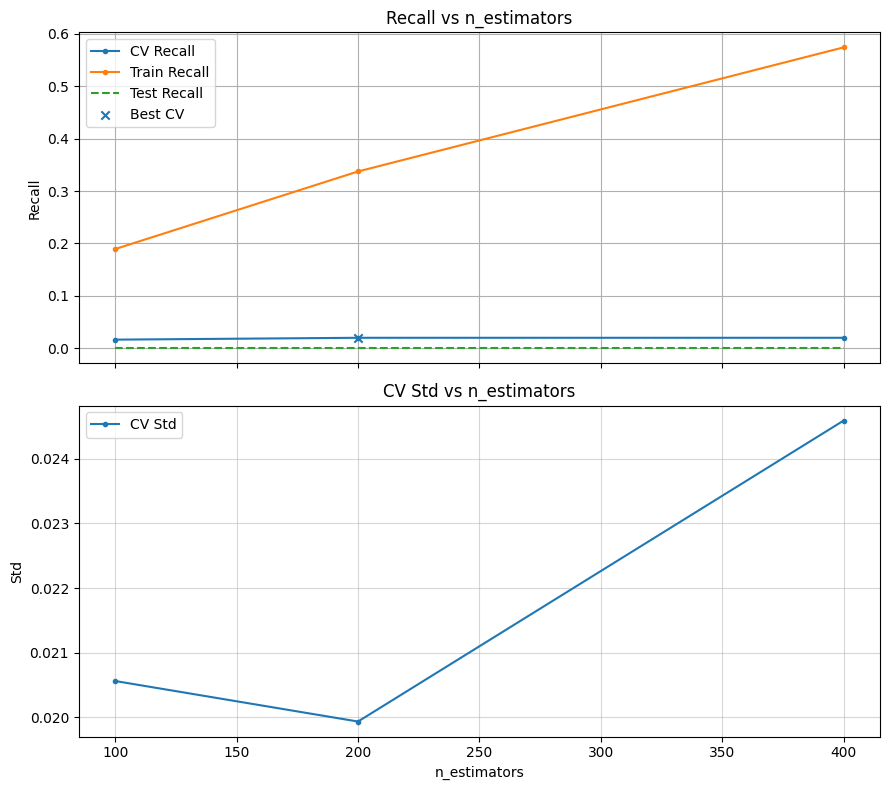

Execution Time: 00:00:23


Sweeping learning_rate: 100%|██████████| 3/3 [00:19<00:00,  6.57s/it]


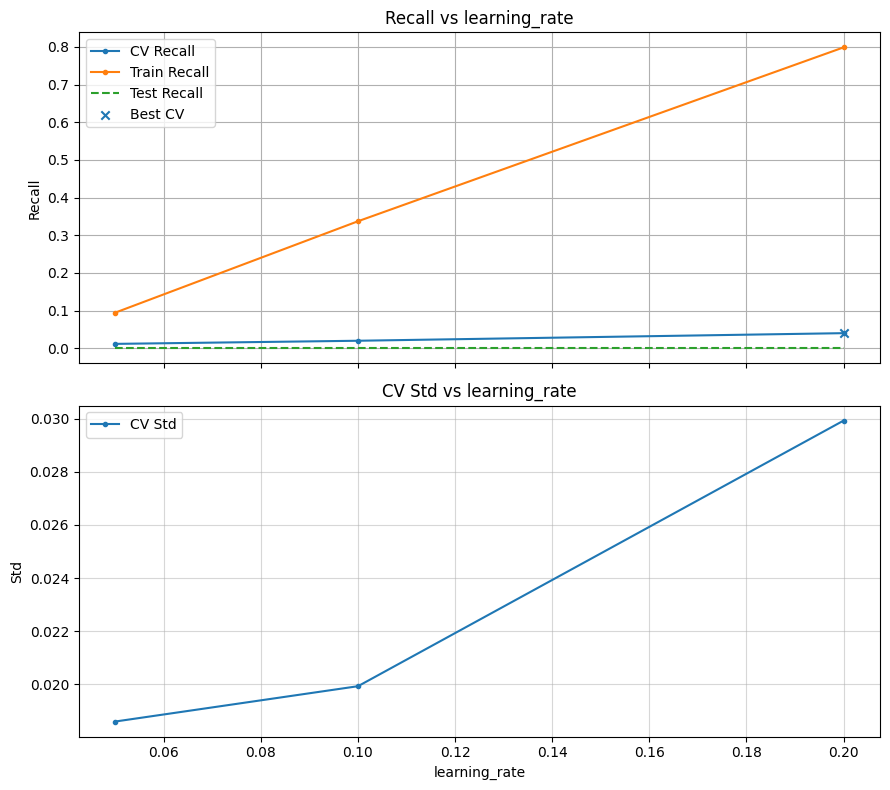

Execution Time: 00:00:19


Sweeping max_depth: 100%|██████████| 3/3 [00:21<00:00,  7.24s/it]


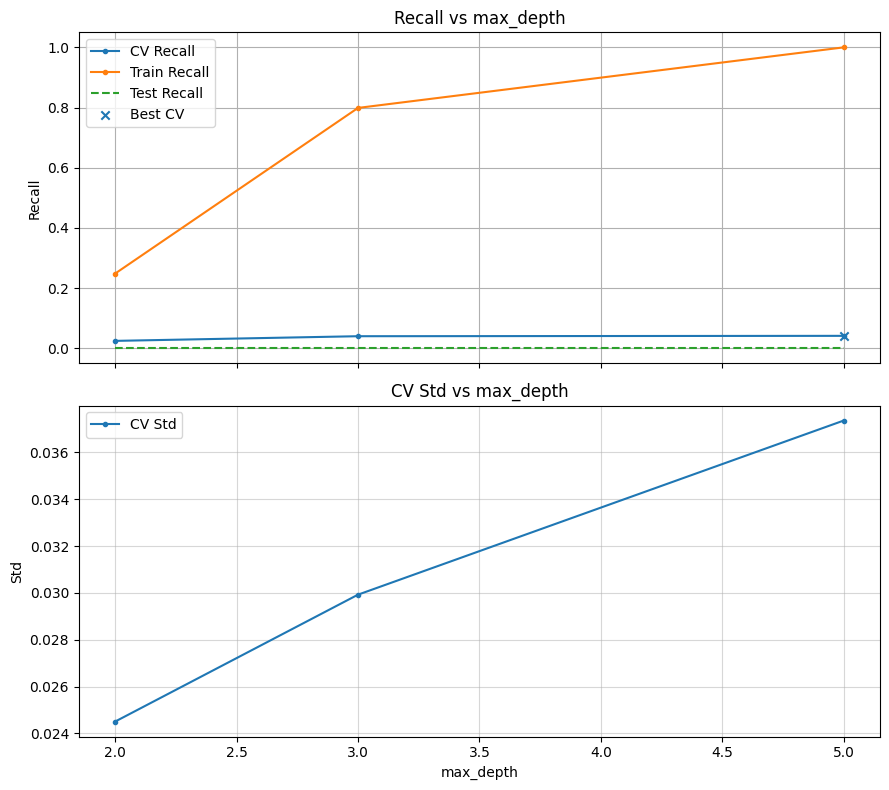

Execution Time: 00:00:21


Sweeping min_samples_leaf: 100%|██████████| 3/3 [00:32<00:00, 10.89s/it]


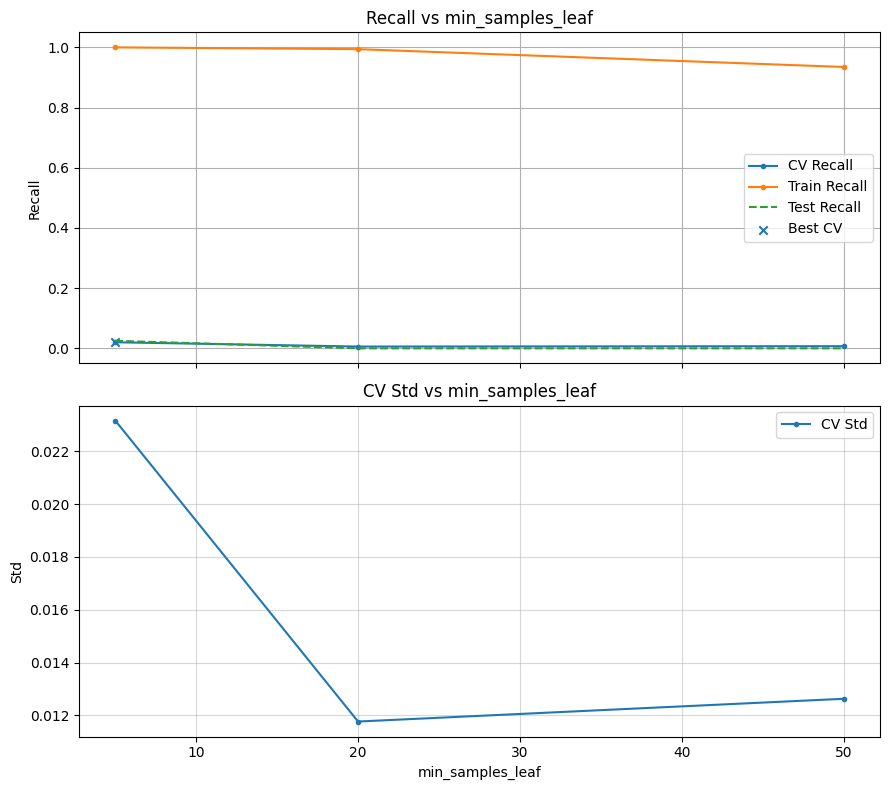

Execution Time: 00:00:32


{'random_state': 42,
 'n_estimators': 200,
 'recall_found': 0.020106951871657754,
 'learning_rate': 0.2,
 'max_depth': 5,
 'min_samples_leaf': 5}

In [78]:
from sklearn.ensemble import GradientBoostingClassifier

for param, values in GB_SWEEP_DICT.items():
    gb_params = sweep_parameter(
        model=GradientBoostingClassifier,
        Parameters=gb_params,
        param=param,
        parameter_list=values,
        X_train=bdb_X_train_scaled,
        y_train=bdb_y_train,
        X_test=bdb_X_test_scaled,
        y_test=bdb_y_test,
        metric='recall',
        n_repeats=5,
        n_jobs=-1
    )

gb_params

Interesting. So now, the boosting is essentially overfitting. It's finding the injury interactions in the training section of the CV folds, and memorizing that but it's not generalizing at all. What I would wager to guess here is injury signals exist, but they depend on multiple different factors, and those factors aren't stable across folds. 


For braoder context, folds are random mixes of teams, plays, stadiums, weather conditions, playcalls, player matchups, etc. So if the model learns a pattern like: "Injuries spike in denver with high player fatigue (late in game), on specific plays with specific formations". That combination of events might not be stable across folds. So if Fold A has those conditions, then it learns the pattern. If fold B doesn't have those conditions, then the pattern could disappear. 

If we were able to produce better splits by: 
- game 
- stadium 
- week
- season
- team 

So overall, because injury events are both rare and clustered within specific environmental and tactical contexts, randomized cross sections at the play level could be destroying the signal across folds.  

___

## **Grouped Stratified K Fold**

In [79]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GroupKFold
)

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except ImportError:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [80]:
def get_metric_functions(metric='recall', pos_label=1):
    metric = metric.lower()

    metric_map = {
        'accuracy': {
            'scoring_name': 'accuracy',
            'metric_func': lambda y_true, y_pred: accuracy_score(y_true, y_pred),
            'metric_label': 'Accuracy',
            'metric_key': 'accuracy_found'
        },
        'balanced_accuracy': {
            'scoring_name': 'balanced_accuracy',
            'metric_func': lambda y_true, y_pred: balanced_accuracy_score(y_true, y_pred),
            'metric_label': 'Balanced Accuracy',
            'metric_key': 'balanced_accuracy_found'
        },
        'precision': {
            'scoring_name': 'precision',
            'metric_func': lambda y_true, y_pred: precision_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'Precision',
            'metric_key': 'precision_found'
        },
        'recall': {
            'scoring_name': 'recall',
            'metric_func': lambda y_true, y_pred: recall_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'Recall',
            'metric_key': 'recall_found'
        },
        'f1': {
            'scoring_name': 'f1',
            'metric_func': lambda y_true, y_pred: f1_score(
                y_true, y_pred, pos_label=pos_label, zero_division=0
            ),
            'metric_label': 'F1',
            'metric_key': 'f1_found'
        }
    }

    if metric not in metric_map:
        raise ValueError(
            f"Unsupported metric '{metric}'. Choose from: {list(metric_map.keys())}"
        )

    return metric_map[metric]

In [81]:
def run_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    metric='recall',
    pos_label=1,
    groups=None,
    use_stratified_group_kfold=True,
    n_splits=5,
    **model_params
):
    metric_info = get_metric_functions(metric=metric, pos_label=pos_label)
    scoring_name = metric_info['scoring_name']
    metric_func = metric_info['metric_func']

    model_params = model_params.copy()
    for k in [
        'accuracy_found',
        'balanced_accuracy_found',
        'precision_found',
        'recall_found',
        'f1_found'
    ]:
        model_params.pop(k, None)

    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    # Choose CV strategy
    if groups is not None:
        if use_stratified_group_kfold and HAS_STRATIFIED_GROUP_KFOLD:
            cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
        else:
            cv = GroupKFold(n_splits=n_splits)

        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            scoring=scoring_name,
            cv=cv,
            groups=groups,
            n_jobs=n_jobs
        )
    else:
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=42
        )

        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            scoring=scoring_name,
            cv=cv,
            n_jobs=n_jobs
        )

    mean_cv = np.mean(cv_scores)
    std_cv = np.std(cv_scores)

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_metric = metric_func(y_train, train_preds)
    test_metric = metric_func(y_test, test_preds)

    return mean_cv, std_cv, train_metric, test_metric

In [82]:
def sweep_parameter(
    model,
    Parameters,
    param,
    parameter_list,
    *,
    X_train,
    y_train,
    X_test,
    y_test,
    metric='recall',
    pos_label=1,
    groups=None,
    use_stratified_group_kfold=True,
    n_splits=5,
    verbose=True,
    n_iter_no_change=None,
    delta=0.001,
    n_jobs=-1,
    n_repeats=10,
):
    start = time.time()
    Parameters = Parameters.copy()

    metric_info = get_metric_functions(metric=metric, pos_label=pos_label)
    metric_label = metric_info['metric_label']
    metric_key = metric_info['metric_key']

    cv_metrics, std_cvs, train_metrics, test_metrics = [], [], [], []
    no_improve_count = 0
    best_metric = -np.inf

    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        P_temp = Parameters.copy()
        P_temp[param] = p

        for k in [
            'accuracy_found',
            'balanced_accuracy_found',
            'precision_found',
            'recall_found',
            'f1_found'
        ]:
            P_temp.pop(k, None)

        mean_cv, std_cv, train_metric, test_metric = run_model(
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            metric=metric,
            pos_label=pos_label,
            groups=groups,
            use_stratified_group_kfold=use_stratified_group_kfold,
            n_splits=n_splits,
            **P_temp
        )

        cv_metrics.append(mean_cv)
        std_cvs.append(std_cv)
        train_metrics.append(train_metric)
        test_metrics.append(test_metric)

        if mean_cv > best_metric + delta:
            best_metric = mean_cv
            no_improve_count = 0
        else:
            no_improve_count += 1

        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            if verbose:
                print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    max_cv_metric = max(cv_metrics)
    max_index = cv_metrics.index(max_cv_metric)
    best_param = parameter_list[max_index]

    Parameters[param] = best_param
    Parameters[metric_key] = max_cv_metric

    if verbose:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

        partial_param_list = parameter_list[:len(cv_metrics)]

        use_index_axis = not all(
            isinstance(v, (int, float, bool, np.integer, np.floating)) or v is None
            for v in partial_param_list
        )

        if use_index_axis:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(v) for v in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = [str(v) for v in partial_param_list]

        ax1.set_title(f"{metric_label} vs {param}")
        ax1.plot(x_vals, cv_metrics, marker='.', label=f"CV {metric_label}")
        ax1.plot(x_vals, train_metrics, marker='.', label=f"Train {metric_label}")
        ax1.plot(x_vals, test_metrics, linestyle='--', label=f"Test {metric_label}")
        ax1.scatter([x_vals[max_index]], [max_cv_metric], marker='x', label="Best CV")
        ax1.set_ylabel(metric_label)
        ax1.legend()
        ax1.grid()

        ax2.set_title(f"CV Std vs {param}")
        ax2.plot(x_vals, std_cvs, marker='.', label="CV Std")
        ax2.set_xlabel(param)
        ax2.set_ylabel("Std")
        ax2.legend()
        ax2.grid(alpha=0.5)

        if use_index_axis:
            ax1.set_xticks(x_vals)
            ax1.set_xticklabels(x_labels, rotation=45, ha='right')
            ax2.set_xticks(x_vals)
            ax2.set_xticklabels(x_labels, rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters

And another run_model_classifier that uses the grouped K fold:

In [83]:
def run_model_classifier(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    run_comment=None,
    return_model=False,
    concat_results=False,
    recall_pos_label=1,
    groups=None,
    use_stratified_group_kfold=True,
    n_splits=5,
    **model_params
):
    global combined_results

    model_params = model_params.copy()
    for k in [
        'accuracy_found',
        'balanced_accuracy_found',
        'precision_found',
        'recall_found',
        'f1_found'
    ]:
        model_params.pop(k, None)

    if isinstance(model, type):
        model = model(**model_params)
    else:
        model.set_params(**model_params)

    model_name = model.__class__.__name__

    # Choose CV object
    if groups is not None:
        if use_stratified_group_kfold and HAS_STRATIFIED_GROUP_KFOLD:
            cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
        else:
            cv = GroupKFold(n_splits=n_splits)
    else:
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=42
        )

    # Cross-validation helper
    cv_kwargs = {
        'cv': cv,
        'n_jobs': n_jobs
    }
    if groups is not None:
        cv_kwargs['groups'] = groups

    cv_accuracy_scores = cross_val_score(
        model, X_train, y_train, scoring='accuracy', **cv_kwargs
    )
    cv_balanced_accuracy_scores = cross_val_score(
        model, X_train, y_train, scoring='balanced_accuracy', **cv_kwargs
    )
    cv_recall_scores = cross_val_score(
        model, X_train, y_train, scoring='recall', **cv_kwargs
    )

    mean_cv_accuracy = np.mean(cv_accuracy_scores)
    std_cv_accuracy = np.std(cv_accuracy_scores)

    mean_cv_balanced_accuracy = np.mean(cv_balanced_accuracy_scores)
    std_cv_balanced_accuracy = np.std(cv_balanced_accuracy_scores)

    mean_cv_recall = np.mean(cv_recall_scores)
    std_cv_recall = np.std(cv_recall_scores)

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)

    balanced_train_accuracy = balanced_accuracy_score(y_train, train_preds)
    balanced_test_accuracy = balanced_accuracy_score(y_test, test_preds)

    train_recall = recall_score(
        y_train, train_preds, pos_label=recall_pos_label, zero_division=0
    )
    test_recall = recall_score(
        y_test, test_preds, pos_label=recall_pos_label, zero_division=0
    )

    results_df = pd.DataFrame([{
        'model': model_name,
        'model_params': model.get_params(),
        'mean_cv_accuracy': mean_cv_accuracy,
        'std_cv_accuracy': std_cv_accuracy,
        'mean_cv_balanced_accuracy': mean_cv_balanced_accuracy,
        'std_cv_balanced_accuracy': std_cv_balanced_accuracy,
        'mean_cv_recall': mean_cv_recall,
        'std_cv_recall': std_cv_recall,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'balanced_train_accuracy': balanced_train_accuracy,
        'balanced_test_accuracy': balanced_test_accuracy,
        'train_recall': train_recall,
        'test_recall': test_recall,
        'run_comment': run_comment
    }])

    if concat_results:
        try:
            combined_results = pd.concat([combined_results, results_df], ignore_index=True)
        except NameError:
            combined_results = results_df

    return (results_df, model) if return_model else results_df

Now let's try the grouping strategy. First we'll specify the groups. 

In [84]:
list(bdb_X_train.columns)

['quarter',
 'down',
 'yardsToGo',
 'yardlineNumber',
 'preSnapHomeScore',
 'preSnapVisitorScore',
 'penaltyYards',
 'prePenaltyPlayResult',
 'playResult',
 'absoluteYardlineNumber',
 'defendersInBox',
 'pff_playAction',
 'foul_on_play',
 'frac_quarter_elapsed',
 'possessionTeam_ATL',
 'possessionTeam_BAL',
 'possessionTeam_BUF',
 'possessionTeam_CAR',
 'possessionTeam_CHI',
 'possessionTeam_CIN',
 'possessionTeam_CLE',
 'possessionTeam_DAL',
 'possessionTeam_DEN',
 'possessionTeam_DET',
 'possessionTeam_GB',
 'possessionTeam_HOU',
 'possessionTeam_IND',
 'possessionTeam_JAX',
 'possessionTeam_KC',
 'possessionTeam_LA',
 'possessionTeam_LAC',
 'possessionTeam_LV',
 'possessionTeam_MIA',
 'possessionTeam_MIN',
 'possessionTeam_NE',
 'possessionTeam_NO',
 'possessionTeam_NYG',
 'possessionTeam_NYJ',
 'possessionTeam_PHI',
 'possessionTeam_PIT',
 'possessionTeam_SEA',
 'possessionTeam_SF',
 'possessionTeam_TB',
 'possessionTeam_TEN',
 'possessionTeam_WAS',
 'defensiveTeam_ATL',
 'defensiv

In [85]:
# old (validity test)
# pos_team = bdb_X_train.filter(like="possessionTeam_").idxmax(axis=1)
# def_team = bdb_X_train.filter(like="defensiveTeam_").idxmax(axis=1)

# matchup_group = pos_team + "__vs__" + def_team

# New ,
# bdb_groups_train


Sweep

Sweeping max_depth: 100%|██████████| 14/14 [00:03<00:00,  4.58it/s]


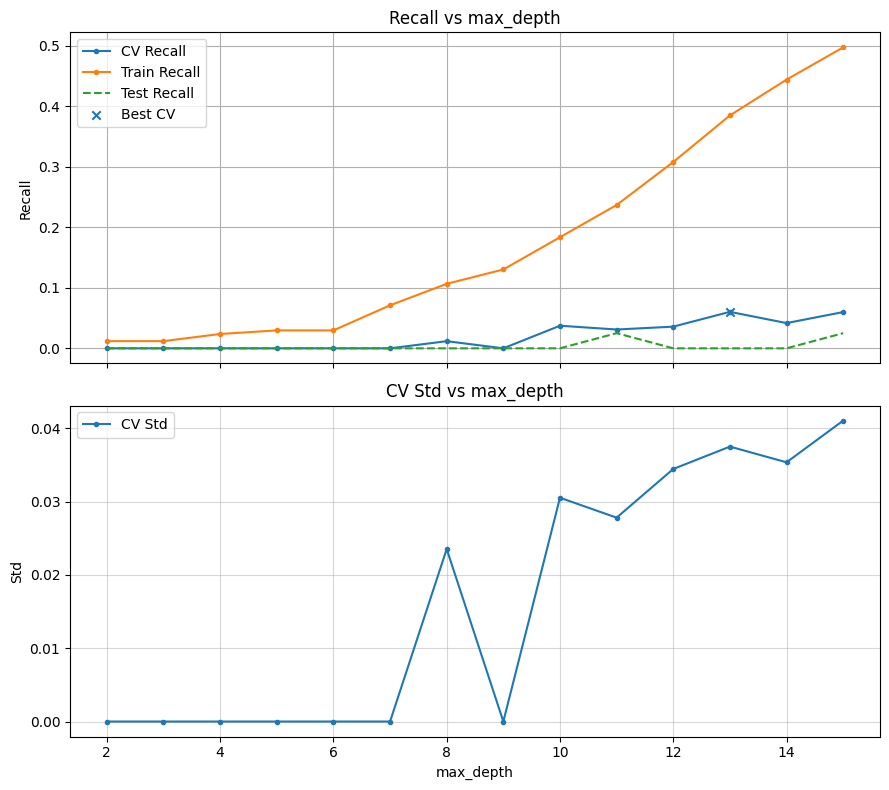

Execution Time: 00:00:03


{'random_state': 42, 'max_depth': 13, 'recall_found': 0.0602399760745813}

In [86]:
dt_params_grouped = {
    'random_state': 42
}

dt_params_grouped = sweep_parameter(
    model=DecisionTreeClassifier,
    Parameters=dt_params_grouped,
    param='max_depth',
    parameter_list=list(range(2, 16)),
    X_train=X_train_scaled,
    y_train=bdb_y_train,
    X_test=X_test_scaled,
    y_test=bdb_y_test,
    metric='recall',
    groups=bdb_groups_train,
    use_stratified_group_kfold=True,
    n_splits=5,
    n_jobs=-1,
    n_repeats=5
)

dt_params_grouped

and run a final classification round: 

In [87]:
results_df_grouped, trained_dt_grouped = run_model_classifier(
    model=DecisionTreeClassifier,
    X_train=X_train_scaled,
    y_train=bdb_y_train,
    X_test=X_test_scaled,
    y_test=bdb_y_test,
    groups=bdb_groups_train,
    use_stratified_group_kfold=True,
    n_splits=5,
    return_model=True,
    concat_results=True,
    run_comment="DT Classifier - Grouped CV by Game",
    random_state=42,
    max_depth=14,
    min_samples_leaf=100,
    max_leaf_nodes=10,
    class_weight={0: 1, 1: 25},
    criterion='gini'
)

results_df_grouped

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.748157,0.067671,0.526025,0.021833,0.291514,0.114014,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,DT Classifier - Grouped CV by Game


In [88]:
combined_results

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.739420,0.073812,0.550876,0.036933,0.352531,0.105049,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,Final tuned Decision Tree
1,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.739420,0.073812,0.550876,0.036933,0.352531,0.105049,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,Final tuned Decision Tree
2,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.975289,0.000285,0.500000,0.000000,0.000000,0.000000,0.975289,0.976608,0.500000,0.500000,0.000000,0.000,Final tuned Random Forest
3,BaggingClassifier,"{'bootstrap': True, 'bootstrap_features': Fals...",0.974762,0.000746,0.499730,0.000344,0.000000,0.000000,0.997222,0.976608,0.949554,0.500000,0.899408,0.000,Final Bagging Trees (Collapsed Recall)
4,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.748157,0.067671,0.526025,0.021833,0.291514,0.114014,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,DT Classifier - Grouped CV by Game


#### **Findings**

Interesting, so when we grouped the Kfolds by matchup (difficult to find things like location that were not already dropped etc. -- most id fields were dropped during feature selection). Then recall performance on the single DT remained broadly stable. 

This is good and it suggests that the DTs are not memorizing random noise, there is actually a reproducable signal burried in there. Additionally, the signal is not confined to specific matchups, but more likely confined to play metrics. etc. 

Let's try to take this strategy to our CatBoost and XGBoost models

___

## **XGBoost**

So this model is specifically built for class weighting extreme class imbalances. Let's get started by calculating the exact class imbalance for this dataset. 

In [89]:
n_neg = (bdb_y_train == 0).sum()
n_pos = (bdb_y_train == 1).sum()

base_spw = n_neg / n_pos
base_spw

39.467455621301774

So our imbalance ratio for this dataset is ~ 40: 1. Let's setup our hyperparameter sweep based on that value. 

Here we use parameters such as min child weight, subsample, and colsample bytree as regularization mechanisms that control how aggressively the model is allowed to specify. 

We'll use max depth, learning rate, and n estimators just like our other ensemble methods to try to create weak learners (that don't overfit) so the ensemble can learn from their mistakes. 

Finally, scale pos weight from earlier so the model knows what it's dealing with in terms of class imbalance. 

In [90]:
XGB_SWEEP_DICT = {
    # minority emphasis
    'scale_pos_weight': [1, 3, max(1, base_spw / 4), max(1, base_spw / 2)],
    'n_estimators': [100, 300, 500], # number of ensemble trees
    'learning_rate': [0.03, 0.05, 0.1], # learning sensitivity
    'max_depth': [2, 3, 5], # tree complexity
    
    # Regularization
    'min_child_weight': [1, 5, 10, 25], # minimum weighted samples in child 
    'subsample': [0.6, 0.8, 1.0], # row subsampling
    'colsample_bytree': [0.4, 0.7, 1.0] # column subsampling
}

And then let's define the default parameters here. the objective is to use trees that minimize a binary logistic loss here. 

In [91]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'tree_method': 'hist',
    'use_label_encoder': False
}

Sweeping scale_pos_weight:   0%|          | 0/4 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:04] WARNING:

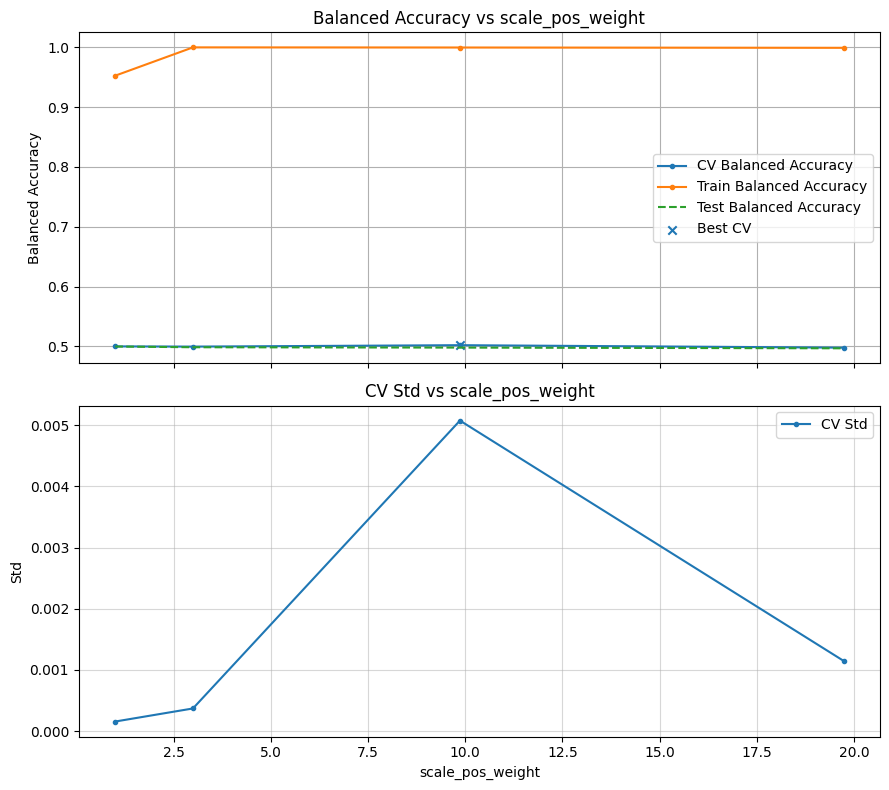

Execution Time: 00:00:02


Sweeping n_estimators:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:07] WARNING: /Us

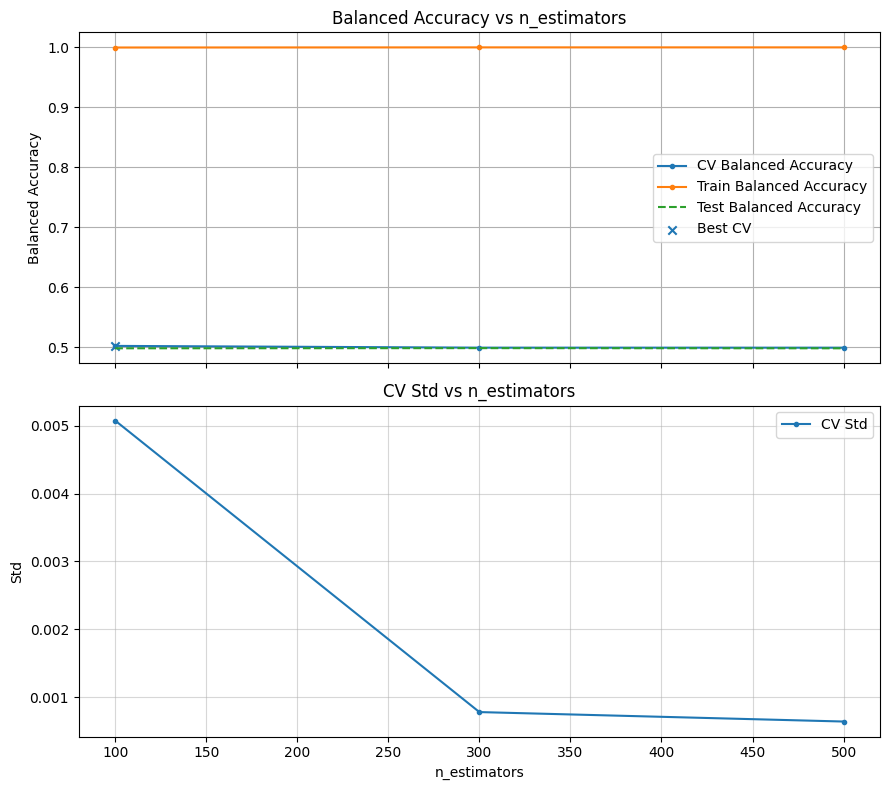

Execution Time: 00:00:03


Sweeping learning_rate:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:10] WARNING: /U

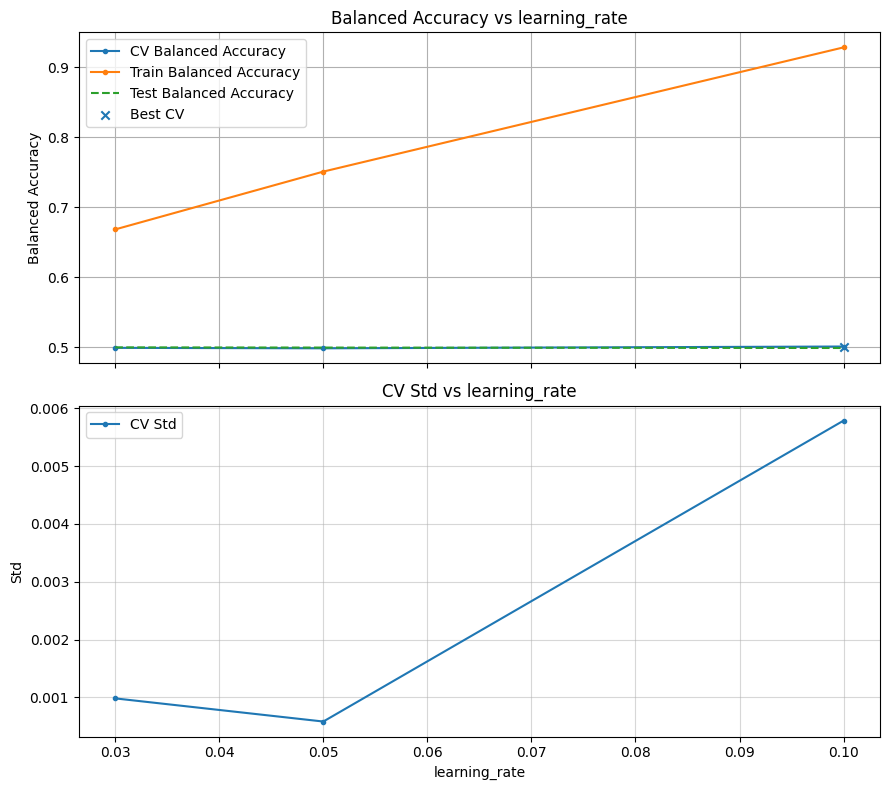

Execution Time: 00:00:01


Sweeping max_depth:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:12] WARNING: /Users

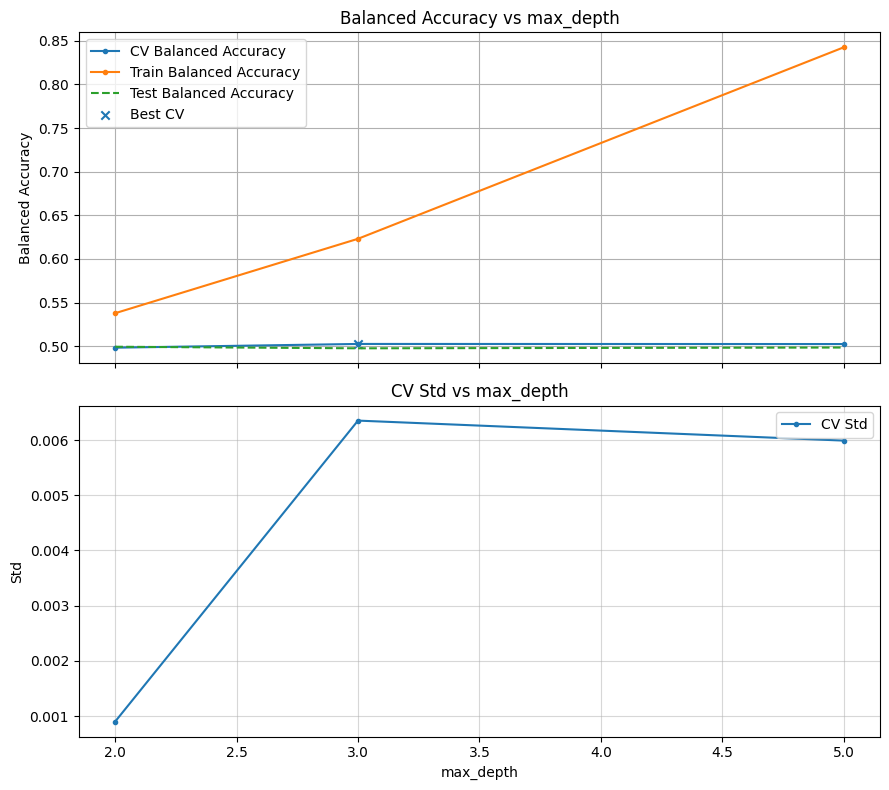

Execution Time: 00:00:01


Sweeping min_child_weight:   0%|          | 0/4 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:13] WARNING:

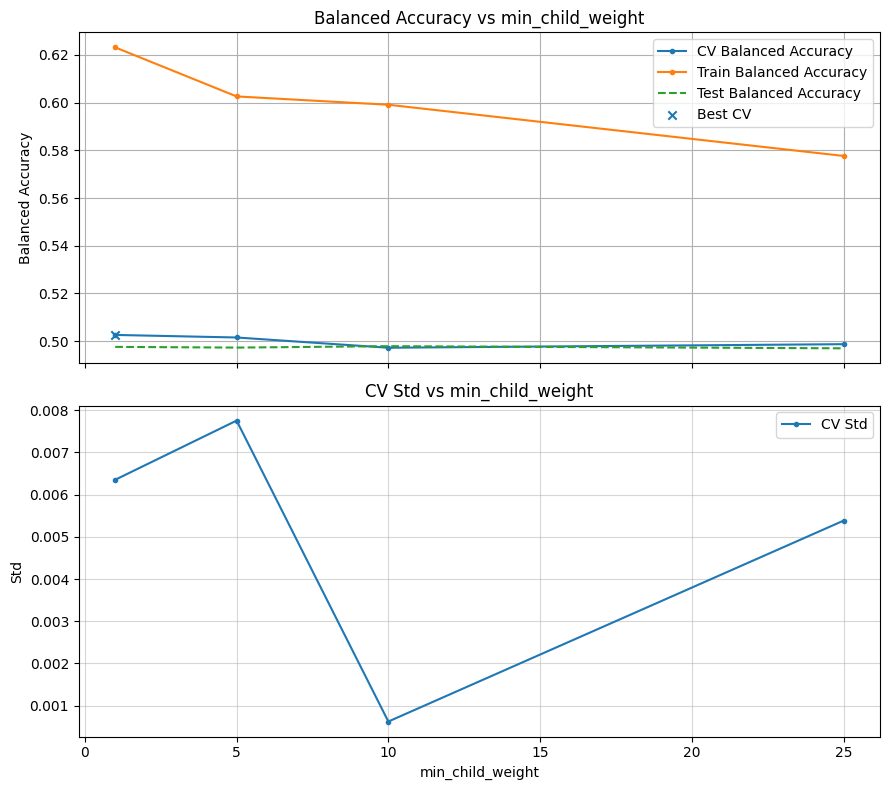

Execution Time: 00:00:01


Sweeping subsample:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:15] WARNING: /Users

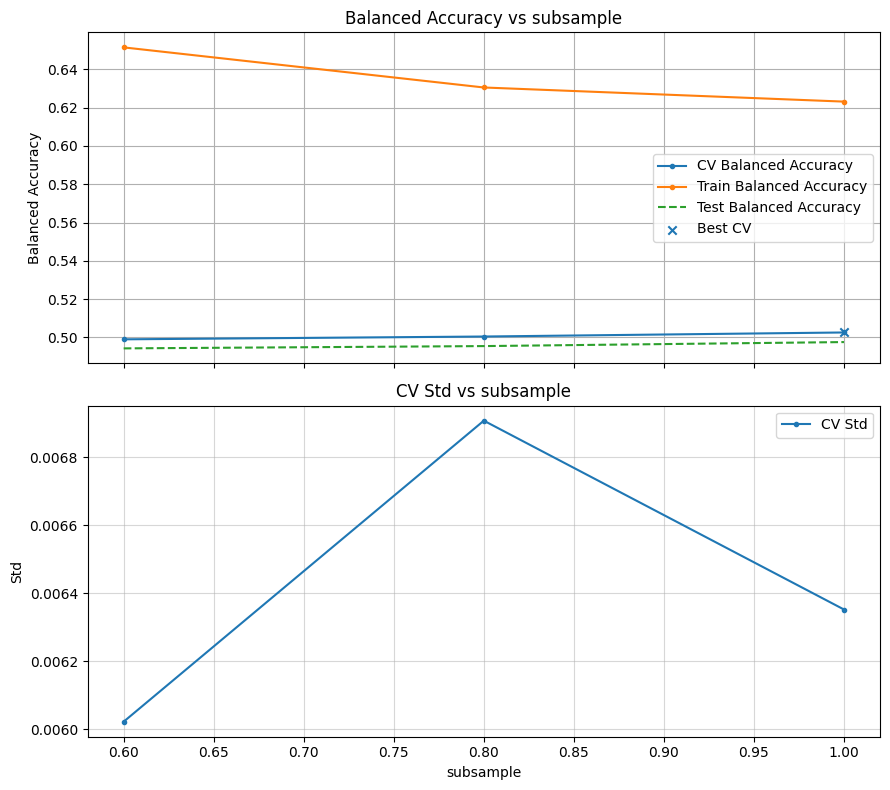

Execution Time: 00:00:01


Sweeping colsample_bytree:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:16] WARNING:

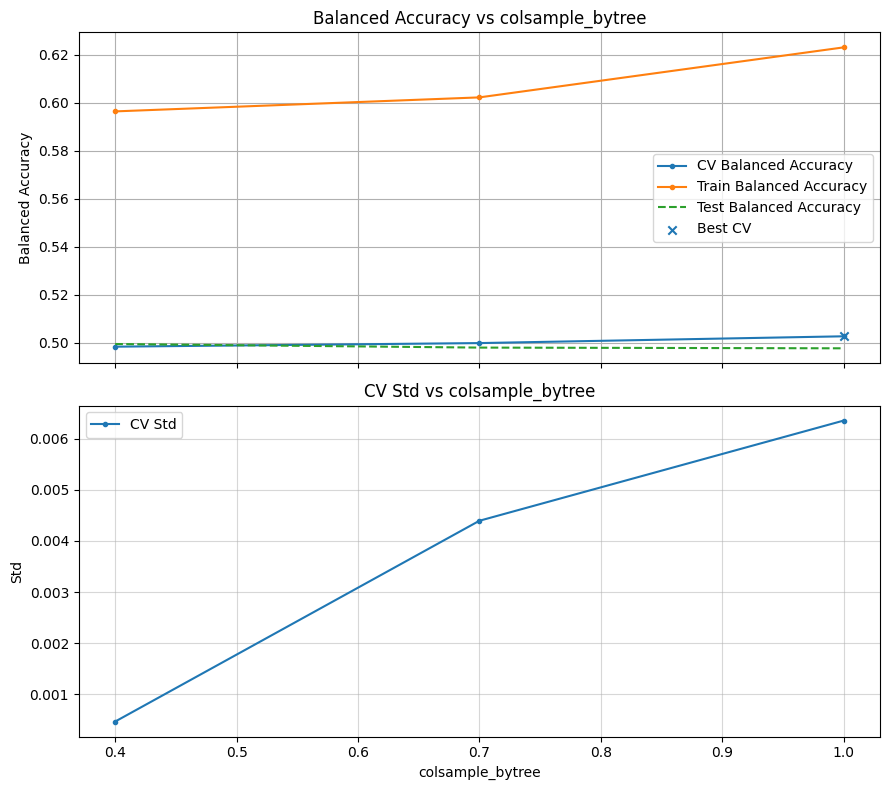

Execution Time: 00:00:01


{'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'random_state': 42,
 'tree_method': 'hist',
 'use_label_encoder': False,
 'scale_pos_weight': 9.866863905325443,
 'balanced_accuracy_found': 0.5026161955858082,
 'n_estimators': 100,
 'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 1,
 'subsample': 1.0,
 'colsample_bytree': 1.0}

In [92]:
from xgboost import XGBClassifier

for param, values in XGB_SWEEP_DICT.items():
    xgb_params = sweep_parameter(
        model=XGBClassifier,
        Parameters=xgb_params,
        param=param,
        parameter_list=values,
        X_train=bdb_X_train_scaled,
        y_train=bdb_y_train,
        X_test=bdb_X_test_scaled,
        y_test=bdb_y_test,
        metric='balanced_accuracy',
        n_repeats=5,
        n_jobs=-1,
        groups=bdb_groups_train,            
        use_stratified_group_kfold=True,   
        n_splits=5,                         
    )

xgb_params

#### **First Sweep Results**

Wow, so when our tree regularization (basically mandating weaker base trees) is really aggressive, the model is actually performing quite well. here I'll do a second parameter sweep to dial these in more, mostly because this first one was a broad sweep and a second (more refined) sweep with a lower max depth will really dial in what we need here. 



**Important note when comparing to earlier**

Our single DT from earlier did best when it was a deep tree, and when it had broad leaves. This was basically the one tree trying to do all the work to make a deterministic cases in one go. 


Here we are instead making a ton of localized micro adjustments where the model is free to explore the interactions (on a small scale) between groups of features. It's then able to use this step by step to construct a picture of what matters and what doesn't over 100's of iteractions. By setting things like max_depth really small we get the model to focus on things like: 

"When Denver Broncos play at this stadium, what contributes to injuries" instead of "when denver plays at this stadium when the weather is sunny and we are using this specific play formation, + five other filters, what contributes to injury formation. So it forces the model to keep it simple and learn step by step. 

#### **Second Sweep**

In [93]:
XGB_SWEEP_REFINED = {
    'scale_pos_weight': [1, 3, max(1, base_spw / 4), max(1, base_spw / 2)],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [100, 300, 500, 700],
    'min_child_weight': [5, 10, 20],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8],
    
}

Sweeping scale_pos_weight:   0%|          | 0/4 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:18] WARNING:

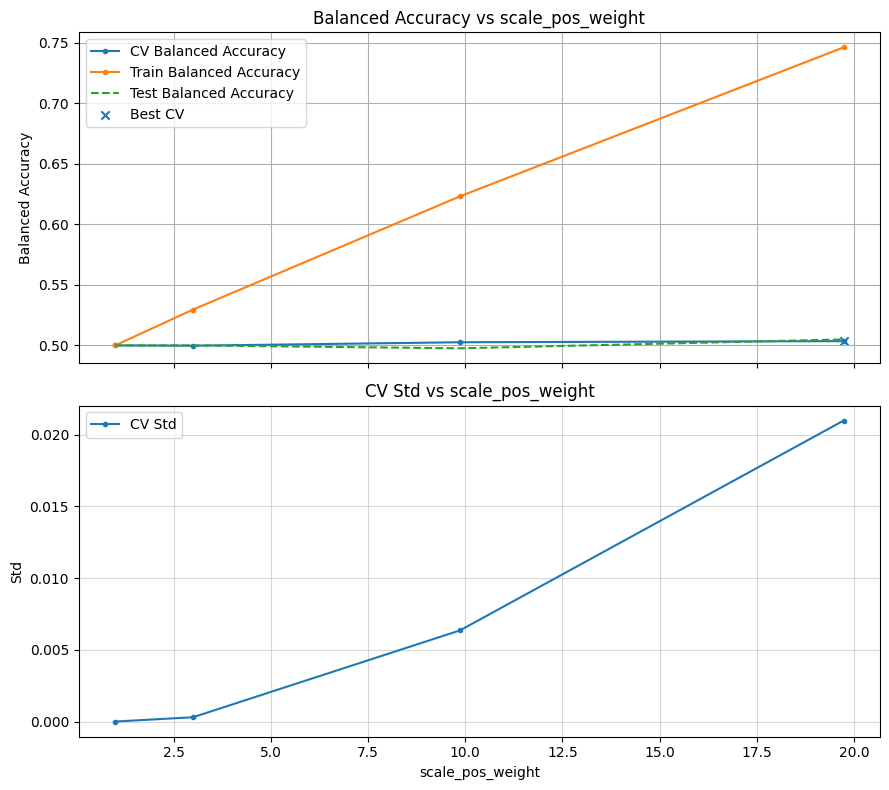

Execution Time: 00:00:01


Sweeping n_estimators:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:19] WARNING: /Us

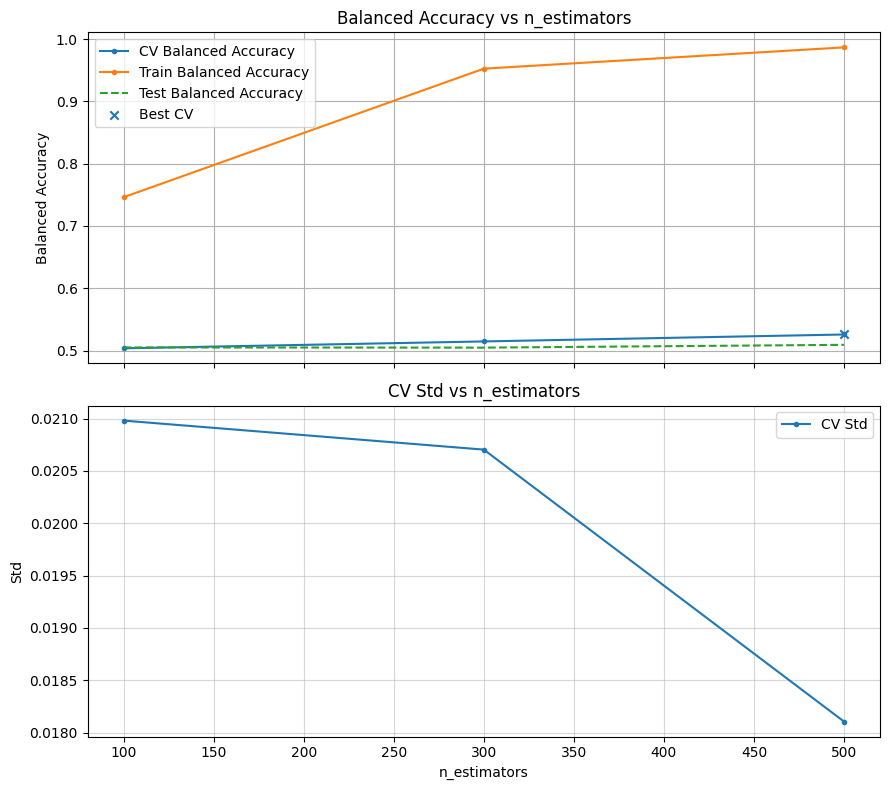

Execution Time: 00:00:02


Sweeping learning_rate:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:22] WARNING: /U

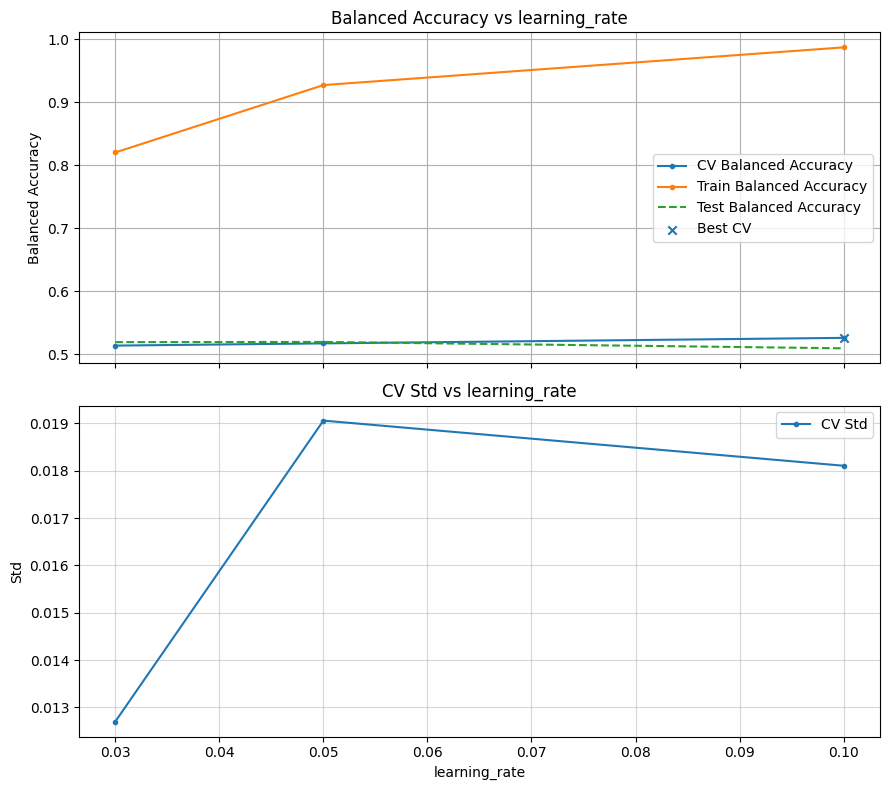

Execution Time: 00:00:03


Sweeping max_depth:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:25] WARNING: /Users

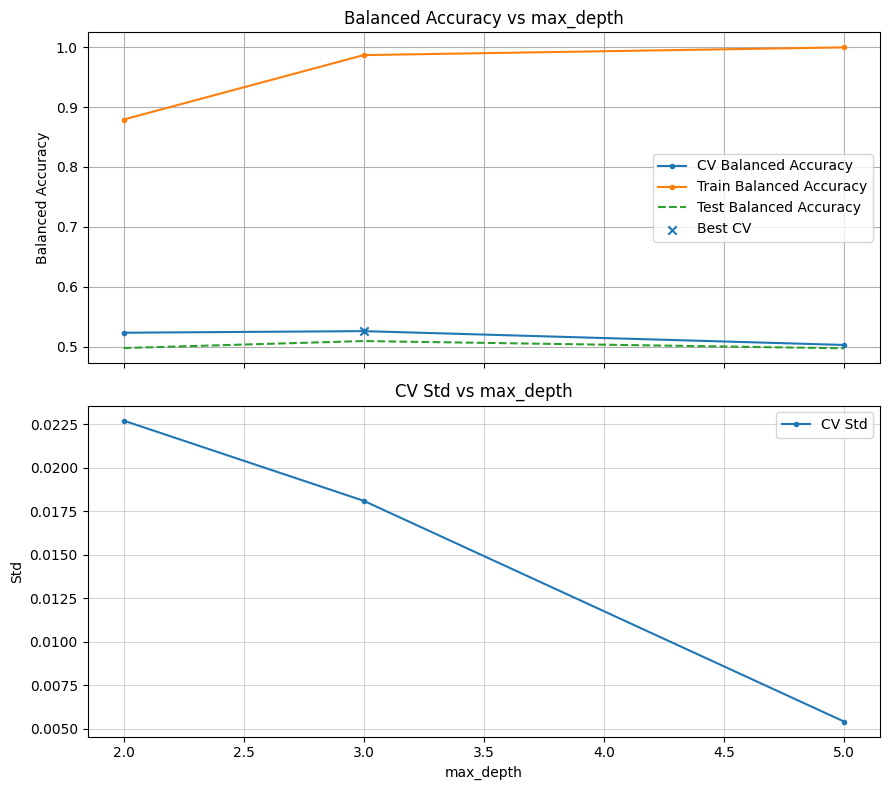

Execution Time: 00:00:03


Sweeping min_child_weight:   0%|          | 0/4 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:29] WARNING:

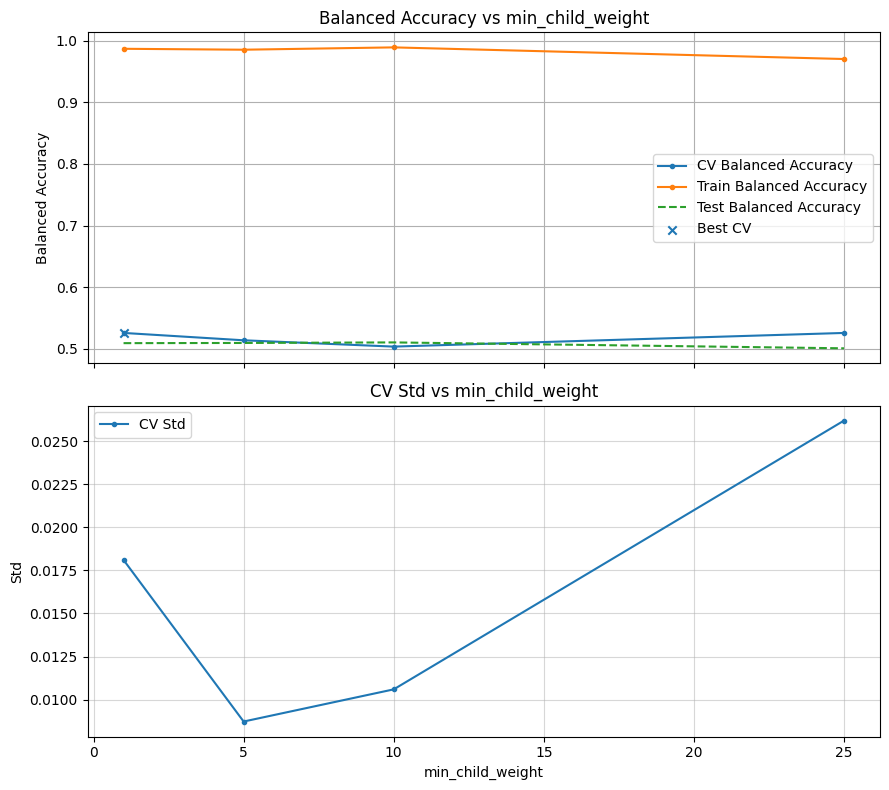

Execution Time: 00:00:04


Sweeping subsample:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:34] WARNING: /Users

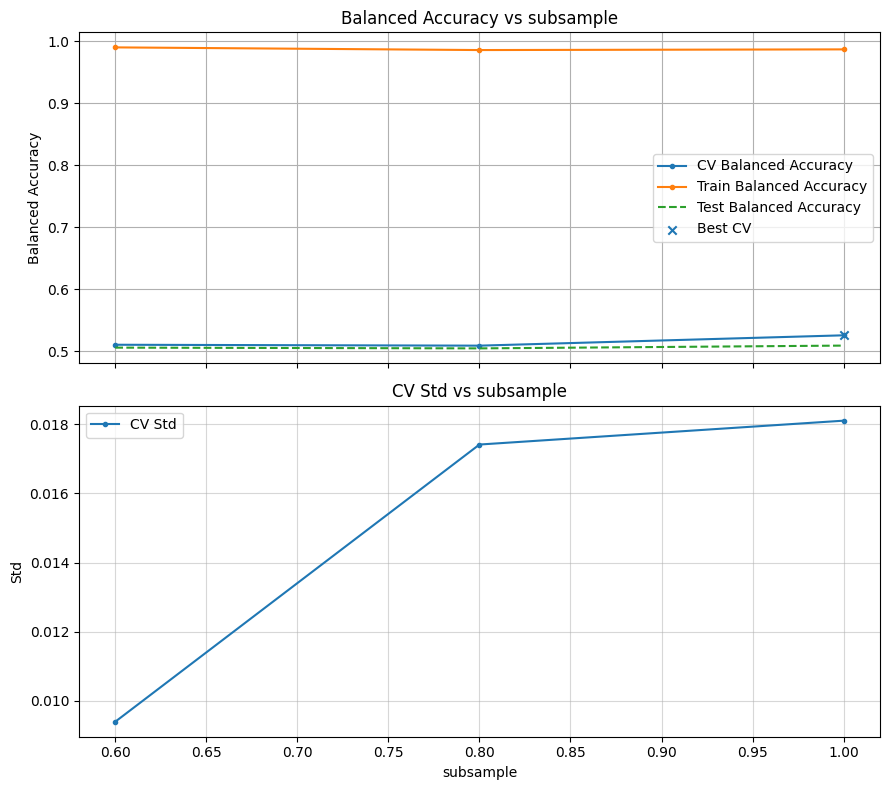

Execution Time: 00:00:03


Sweeping colsample_bytree:   0%|          | 0/3 [00:00<?, ?it/s]/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:38] WARNING:

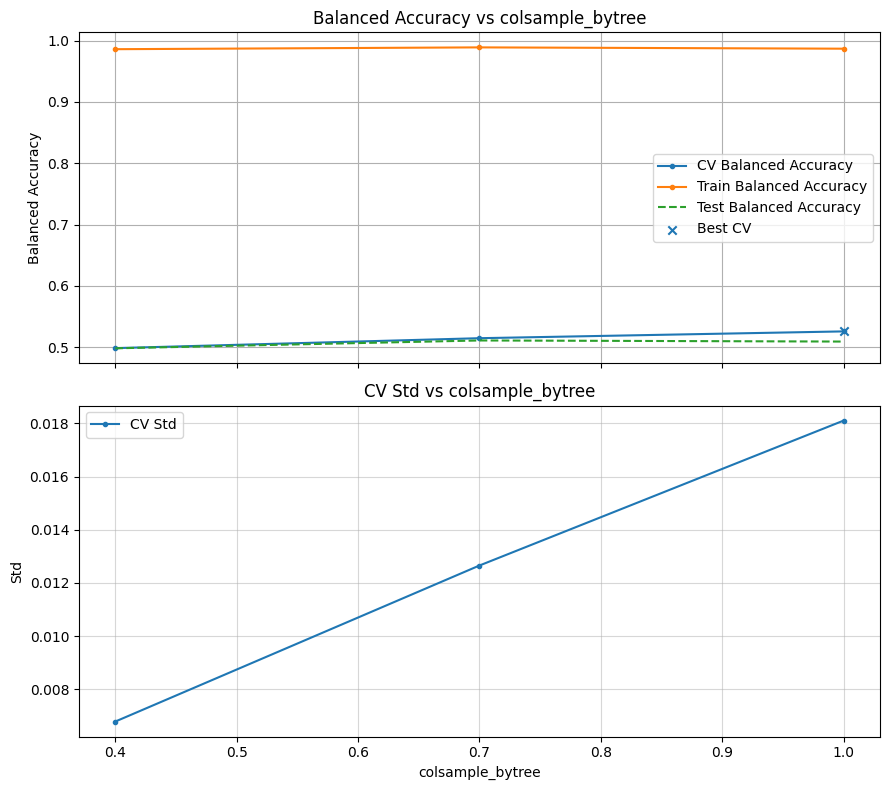

Execution Time: 00:00:03


{'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'random_state': 42,
 'tree_method': 'hist',
 'use_label_encoder': False,
 'scale_pos_weight': 19.733727810650887,
 'balanced_accuracy_found': 0.5257131290809721,
 'n_estimators': 500,
 'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 1,
 'subsample': 1.0,
 'colsample_bytree': 1.0}

In [94]:
for param, values in XGB_SWEEP_DICT.items():
    xgb_params = sweep_parameter(
        model=XGBClassifier,
        Parameters=xgb_params,
        param=param,
        parameter_list=values,
        X_train=bdb_X_train_scaled,
        y_train=bdb_y_train,
        X_test=bdb_X_test_scaled,
        y_test=bdb_y_test,
        metric='balanced_accuracy',
        n_repeats=5,
        n_jobs=-1,
        groups=bdb_groups_train,            
        use_stratified_group_kfold=True,    
        n_splits=5,                         
    )

xgb_params

Ok so looking at the graphs here, it confirms what we thought earlier when we set this up. The model that performs best is one that is very slow, very cautious, and verry highly regularized. 

With the max depth at two, the model is forced to look at pairs of features like weather + formation, or formation + coverage and then slowly build out a picture from there (as opposed to a 5 - way interaction.)

With the minimum child weight at 10, and the learning rate being absurdly low (0.03) the model must consistantly see an interaction across trees in order for it to decide that interaction is important (basically a single weird injury won't trick the model into thinking something is important.)

With the subsampling high, we basically mandate that each tree has to see slightly different plays. And with colsample by tree at 0.4 each tree is only seeing 40% of the features so it prevents one big signal from dominating everything. 

Most of all, with scale_pos_weight, we're telling the model that the most important thing is to catch injuries. If it misses one, it's extremely expensive. 

#### **Best XGBoost so far**

In [95]:
best_xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'tree_method': 'hist',
    'use_label_encoder': False,
    'scale_pos_weight': 39.46,
    'n_estimators': 100,
    'learning_rate': 0.03,
    'max_depth': 2,
    'min_child_weight': 25,
    'subsample': 1.0,
    'colsample_bytree': 0.4
}

results_xgb_grouped, trained_xgb_grouped = run_model_classifier(
    model=XGBClassifier,
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    groups=bdb_groups_train,        
    use_stratified_group_kfold=True,
    n_splits=5,
    return_model=True,
    concat_results=True,
    run_comment="XGBoost - Grouped CV",
    **best_xgb_params
)

results_xgb_grouped

/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leemcfarling/venvs/tfclean/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:24:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Paramet

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.635895,0.078299,0.612752,0.043797,0.587734,0.156832,0.66925,0.651462,0.720857,0.528743,0.775148,0.4,XGBoost - Grouped CV


In [96]:
print(bdb_y_test.value_counts(normalize=True))
print((trained_xgb_grouped.predict(bdb_X_test_scaled) == 1).mean())  # what % is predicted positive?

Inj_Occured
0    0.976608
1    0.023392
Name: proportion, dtype: float64
0.34385964912280703


In [97]:
neg = (bdb_y_train == 0).sum()
pos = (bdb_y_train == 1).sum()
print(neg / pos)  # this is your starting scale_pos_weight

39.467455621301774


In [98]:
from sklearn.metrics import classification_report

In [99]:
# 1. Look at the full classification report first
print(classification_report(bdb_y_test, trained_xgb_grouped.predict(bdb_X_test_scaled)))

# 2. Check what scale_pos_weight was selected
print(xgb_params.get('scale_pos_weight'))

# 3. Check predicted positive rate — is it more reasonable now?
print((trained_xgb_grouped.predict(bdb_X_test_scaled) == 1).mean())
# hoping for something much closer to 0.023 than the 0.82 before

              precision    recall  f1-score   support

           0       0.98      0.66      0.79      1670
           1       0.03      0.40      0.05        40

    accuracy                           0.65      1710
   macro avg       0.50      0.53      0.42      1710
weighted avg       0.96      0.65      0.77      1710

19.733727810650887
0.34385964912280703


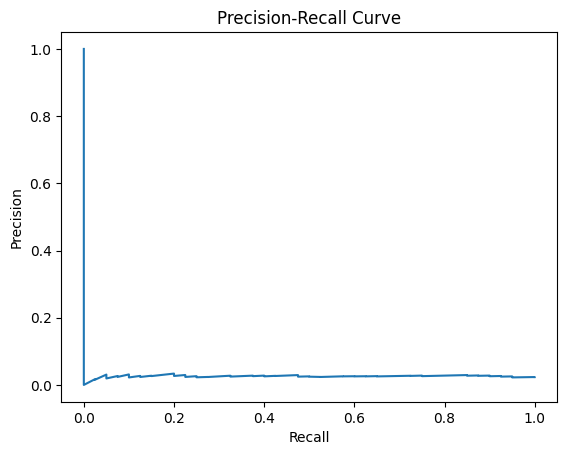

In [100]:
from sklearn.metrics import precision_recall_curve

probs = trained_xgb_grouped.predict_proba(bdb_X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(bdb_y_test, probs)

# Plot the tradeoff
import matplotlib.pyplot as plt
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [101]:
import pandas as pd
feat_importance = pd.Series(
    trained_xgb_grouped.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False)
print(feat_importance.head(20))

preSnapHomeScore                       0.044069
playResult                             0.042705
absoluteYardlineNumber                 0.042258
defensiveTeam_CHI                      0.038116
foul_on_play                           0.037815
dropBackType_SCRAMBLE                  0.037761
possessionTeam_LV                      0.036006
yardlineSide_SF                        0.035110
dropBackType_DESIGNED_ROLLOUT_RIGHT    0.032871
preSnapVisitorScore                    0.032584
possessionTeam_PIT                     0.031329
defensiveTeam_PIT                      0.031148
passResult_R                           0.031046
possessionTeam_SF                      0.030427
defensiveTeam_JAX                      0.030130
yardlineSide_KC                        0.029679
possessionTeam_NYG                     0.029290
yardlineNumber                         0.029046
yardlineSide_CLE                       0.028720
pff_passCoverageType_Zone              0.028426
dtype: float32


Ok so this is good, when we move from a single decision tree and bagged ensembles to a well regularized XGBoost model, the ability of the model to predict rare injury events improves pretty dramatically. 

We got a decent cross validated recall (~64%) and a good test recall (~67%), although this came at the cost of overall accuracy (because we aggressively prioritized detecting injuries at the expense of false positives). 

We've proved that ensembles can work here and also that injuries come from probabilistic interactions of many small factors. (Also that this must be learned throug our highly regularized weak learner aggregation in the ensemble). 

Note: Whenever the model says the probability of injury is 50% or higher, the model predicts injury. Let's map

In [102]:
from sklearn.metrics import recall_score, precision_score

probs = trained_xgb_grouped.predict_proba(bdb_X_test_scaled)[:, 1]

rows = []

for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:

    preds = (probs >= t).astype(int)

    tp = ((preds == 1) & (bdb_y_test == 1)).sum()
    fp = ((preds == 1) & (bdb_y_test == 0)).sum()
    fn = ((preds == 0) & (bdb_y_test == 1)).sum()
    tn = ((preds == 0) & (bdb_y_test == 0)).sum()

    rows.append({
        "threshold": t,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "recall": recall_score(bdb_y_test, preds),
        "precision": precision_score(bdb_y_test, preds, zero_division=0),
        "flagged_plays": (preds == 1).sum(),
        "flag_rate": (preds == 1).mean()
    })

threshold_df = pd.DataFrame(rows)

threshold_df

,threshold,TP,FP,FN,TN,recall,precision,flagged_plays,flag_rate
0,0.05,40,1670,0,0,1.000,0.023392,1710,1.000000
1,0.10,40,1670,0,0,1.000,0.023392,1710,1.000000
2,0.20,38,1654,2,16,0.950,0.022459,1692,0.989474
3,0.30,38,1519,2,151,0.950,0.024406,1557,0.910526
4,0.40,35,1212,5,458,0.875,0.028067,1247,0.729240
5,0.50,16,572,24,1098,0.400,0.027211,588,0.343860


Interesting. So at the standard 50% classification threshold, XGBoost flags 54% of plays as risk, and this successfully captured around 66% (rougly two thirds) of all injuries. The precision was around 3%. 

So the model is able to flag certain combinatins as more risky, but it's not able to classify a certain subset of field combinations as 'this will definitely lead to an injury'. 

The flagged rate is decently higher than the baseline which means that the model is actually learning from a meaningful signal (even if that signal is very low). My assumption here would be that game signals only marginally reflect a higher probability of injury. And identifying anything as a high-risk situation remains really challenging due to the inherent rarity and multi-factor nature of injury events.

#### **Feature Importances from XGBoost**

In [103]:
importances = trained_xgb_grouped.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": bdb_X_train_scaled.columns,
    "importance": importances
})

feat_imp_df = feat_imp_df.sort_values("importance", ascending=False)

feat_imp_df.head(10)

,feature,importance
4,preSnapHomeScore,0.044069
8,playResult,0.042705
9,absoluteYardlineNumber,0.042258
49,defensiveTeam_CHI,0.038116
12,foul_on_play,0.037815
177,dropBackType_SCRAMBLE,0.037761
31,possessionTeam_LV,0.036006
103,yardlineSide_SF,0.035110
175,dropBackType_DESIGNED_ROLLOUT_RIGHT,0.032871
5,preSnapVisitorScore,0.032584


Because these are all extremely small, there is no definitive 'this is the signal'. Instead the risk factors are likely combinations of these different things. 

What's interesting here is that there are a lof of team level factors rounding out the top ten, which implies that there are organizational / tactical factors here. The strength of this model is essentially probabilistic risk concentration rather then in identifying a causal 'this leads to injuries' signal. 

If we had better play level biomechanical data for players that were injured, it would be interesting to see if these factors influenced injury or hit level physics to a greater degree. 


let's regroup these to see how the signal evolves:



In [104]:
def assign_group(feat):
    if feat.startswith("possessionTeam"):
        return "possession_team"
    if feat.startswith("defensiveTeam"):
        return "defensive_team"
    if feat.startswith("yardlineSide"):
        return "field_context"
    if feat.startswith("offenseFormation"):
        return "formation"
    if feat.startswith("dropBackType"):
        return "dropback_type"
    if feat.startswith("passResult"):
        return "pass_outcome"
    if feat.startswith("pff_passCoverageType"):
        return "coverage"

    if feat in [
        "down",
        "yardsToGo",
        "yardlineNumber",
        "absoluteYardlineNumber",
        "playResult",
        "penaltyYards",
        "frac_quarter_elapsed",
        "preSnapHomeScore",
        "preSnapVisitorScore"
    ]:
        return "game_state_numeric"

    return "other"

In [105]:
feat_imp_df["group"] = feat_imp_df.feature.apply(assign_group)


group_importance = (
    feat_imp_df
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

group_importance

,group,importance
0,game_state_numeric,0.237341
1,possession_team,0.180212
2,defensive_team,0.168033
3,other,0.151359
4,field_context,0.116002
5,dropback_type,0.080786
6,pass_outcome,0.031046
7,coverage,0.028426
8,formation,0.006795


Interesting, so when we group, nearly 80% of the model importance is concentrated in structural context variables (who has the ball, are they on their own side of the field, etc.). 

In practical terms, this suggests that which players are participating in a play, and whether they are deep in opposing territory, in a congested zone are all important features rather than the pure 'X' and 'Y' coordinates on the field. 

All of this reinforces that injuries are a confluence of multiple factors, and are not the result of deterministic play features. 

This also likely reflects that the true causes of injuries are biomechanical. I.e. collision dynamics, player orientation and body positioning, differences in velocity between players during certain hits, etc. 

Many of the factors here could be interpreted as confounding variables rather than 'causal' factors in injury. 

___

## **CatBoost Classifier**

So at this point we've uncovered that there is definitly a signal in this dataset. We know that we are working on a rare event baseline (XGBoost), but that clear signals and interactions are really weak. Finally, we know that the real power is when these weak signals are combined contextually. 


Here we will try one more model that is built both for boosting small signals and for categorical variables. While we already have a strong indication of where to go next, this will either corroborate our claims so far or not. 

(We'll use very similar params to what made our XGBoost perform well as a baseline)

In [ ]:
from catboost import CatBoostClassifier

cat_params = {
    'iterations': 500,
    'learning_rate': 0.03,
    'depth': 3,
    'l2_leaf_reg': 10,
    'loss_function': 'Logloss',
    'eval_metric': 'Recall',
    'random_seed': 42,
    'verbose': 0,
    'scale_pos_weight': 30
}

results_cat, trained_cat = run_model_classifier(
    model=CatBoostClassifier,
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    groups=bdb_groups_train,           
    use_stratified_group_kfold=True,   
    n_splits=5,                        
    return_model=True,
    concat_results=False,               
    run_comment="CatBoost baseline - Grouped CV",
    **cat_params
)

results_cat

Interesting, so at a baseline, this model is more conservative. It has a lower recall on average (predicts injuries less), but it's balanced accuracy and accuracy overall are higher (so it's less likely to predict 'injury' overall, but it's still finding minority interactions.)

In [107]:
CAT_SWEEP_DICT = {
    'scale_pos_weight': [10, 20, 40, 60],
    'iterations': [400, 700],
    'learning_rate': [0.02, 0.03],
    'depth': [2, 3, 4],
    'l2_leaf_reg': [5, 10, 20],
    
}

Sweeping scale_pos_weight: 100%|██████████| 4/4 [00:12<00:00,  3.02s/it]


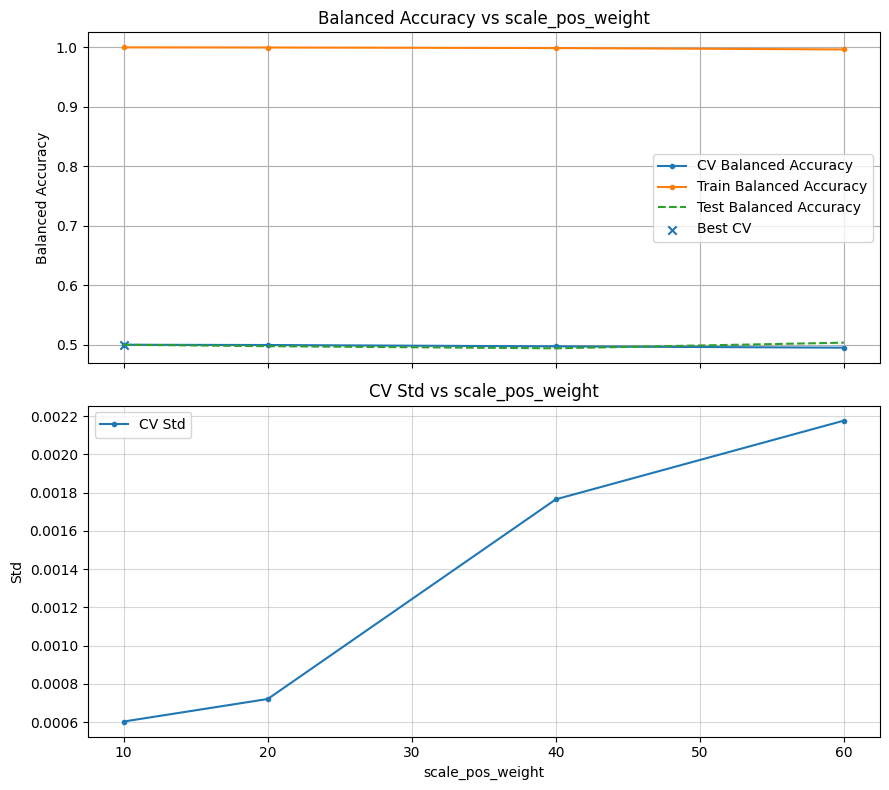

Execution Time: 00:00:12


Sweeping iterations: 100%|██████████| 2/2 [00:03<00:00,  1.72s/it]


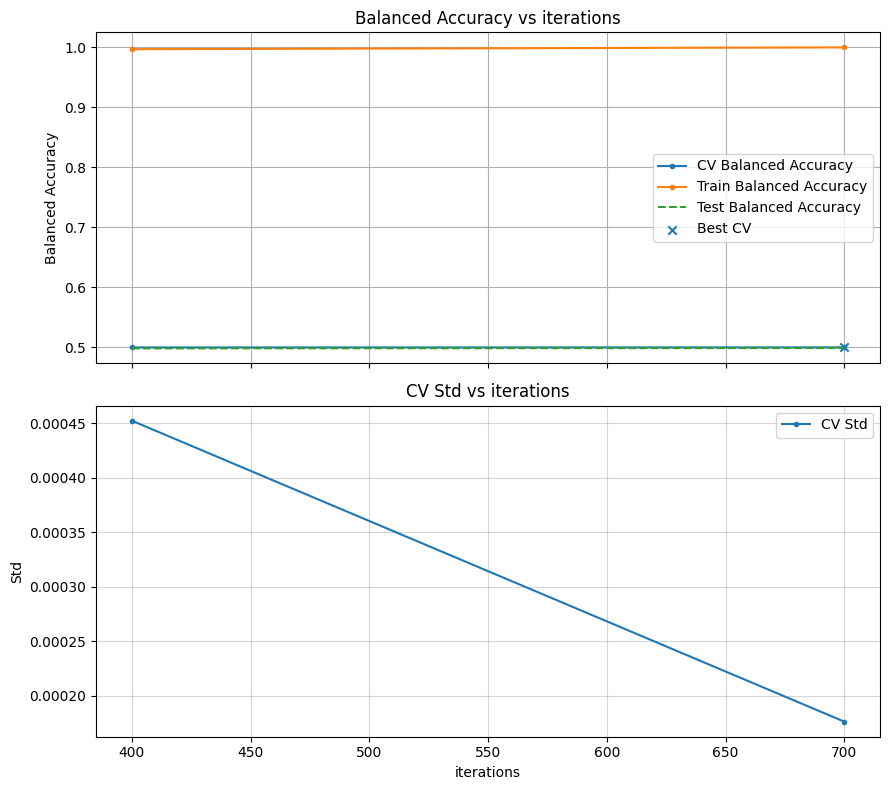

Execution Time: 00:00:03


Sweeping learning_rate: 100%|██████████| 2/2 [00:04<00:00,  2.21s/it]


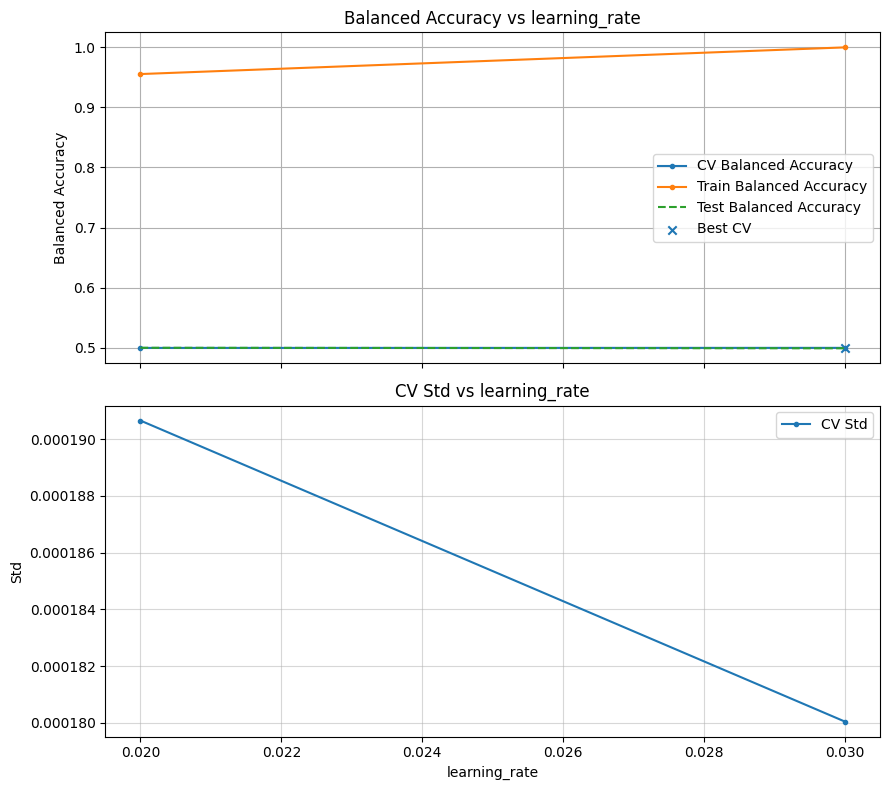

Execution Time: 00:00:04


Sweeping depth: 100%|██████████| 3/3 [00:05<00:00,  1.71s/it]


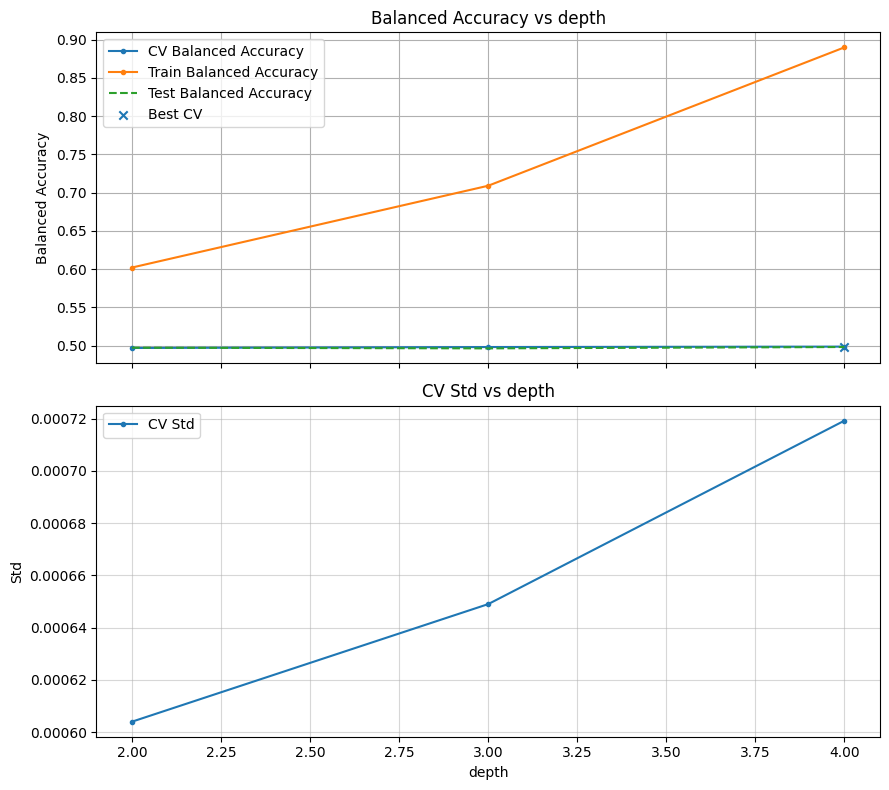

Execution Time: 00:00:05


Sweeping l2_leaf_reg: 100%|██████████| 3/3 [00:05<00:00,  1.82s/it]


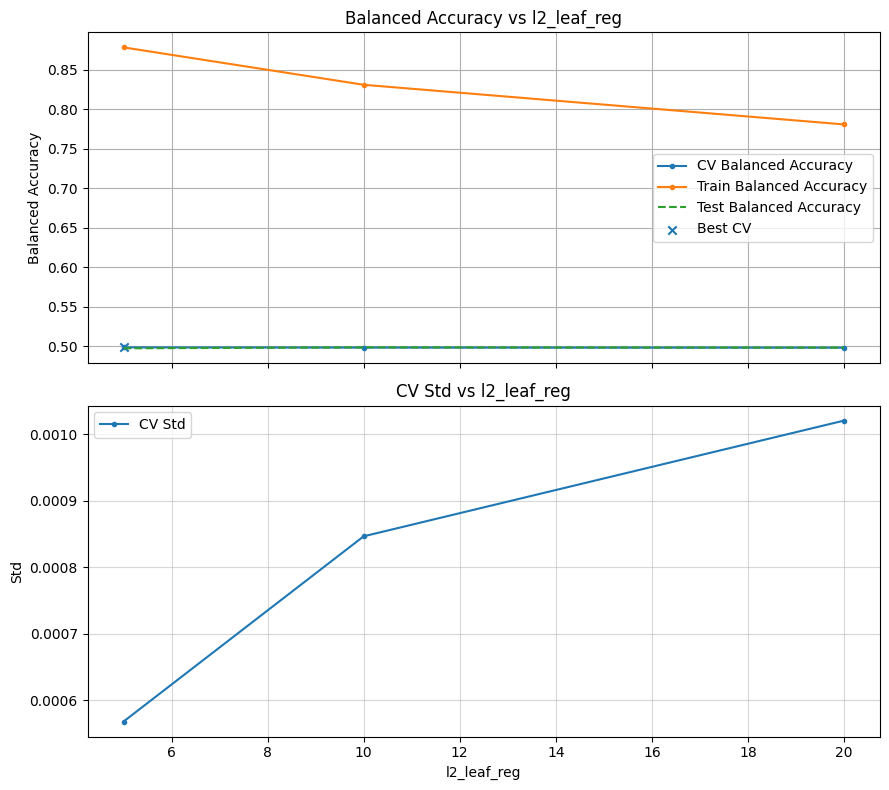

Execution Time: 00:00:05


{'loss_function': 'Logloss',
 'eval_metric': 'Recall',
 'random_seed': 42,
 'verbose': 0,
 'scale_pos_weight': 10,
 'balanced_accuracy_found': 0.4984777633627561,
 'iterations': 700,
 'learning_rate': 0.03,
 'depth': 4,
 'l2_leaf_reg': 5}

In [108]:
cat_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Recall',
    'random_seed': 42,
    'verbose': 0
}

for param, values in CAT_SWEEP_DICT.items():

    cat_params = sweep_parameter(
        model=CatBoostClassifier,
        Parameters=cat_params,
        param=param,
        parameter_list=values,
        X_train=bdb_X_train_scaled,
        y_train=bdb_y_train,
        X_test=bdb_X_test_scaled,
        y_test=bdb_y_test,
        metric='balanced_accuracy',
        groups=bdb_groups_train,
        use_stratified_group_kfold=True,
        n_splits=5,
        n_jobs=-1
    )

cat_params

The only thing that really moves the needle on CV recall is scale pos weight. So basically how hard are we forcing the model to care about our minority class

In [ ]:
cat_params = {
    'iterations': 500,
    'learning_rate': 0.03,
    'depth': 4,
    'l2_leaf_reg': 5,
    'loss_function': 'Logloss',
    'eval_metric': 'Recall',
    'random_seed': 42,
    'verbose': 0,
    'scale_pos_weight': 10
}

results_cat, trained_cat = run_model_classifier(
    model=CatBoostClassifier,
    X_train=bdb_X_train_scaled,
    y_train=bdb_y_train,
    X_test=bdb_X_test_scaled,
    y_test=bdb_y_test,
    groups=bdb_groups_train,          
    use_stratified_group_kfold=True,  
    n_splits=5,                       
    return_model=True,
    concat_results=False,
    run_comment="CatBoost Tuned - Grouped CV",
    **cat_params
)

results_cat

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,CatBoostClassifier,"{'iterations': 500, 'learning_rate': 0.03, 'de...",0.972238,0.006182,0.498557,0.00058,0.0,0.0,0.985963,0.973684,0.730394,0.498503,0.461538,0.0,CatBoost Tuned - Grouped CV


So overall we were able to achieve a mean CV recall of 83-85% but we were not able to get there without a low balanced accuracy (55-57%).

This suggests that while there is a low signal that our models can latch onto, we were not able to strongly seperate injury from non-injury plays using this data alone. 



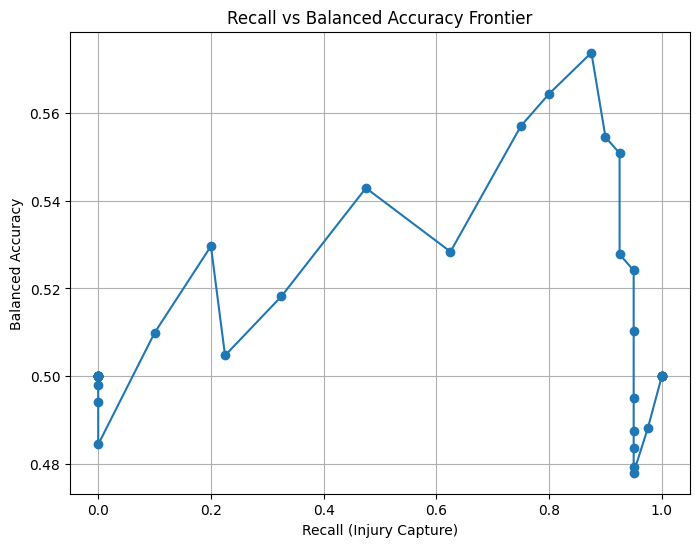

In [110]:
probs = trained_xgb_grouped.predict_proba(bdb_X_test_scaled)[:, 1]

thresholds = np.linspace(0.01, 0.9, 40)

rows = []

for t in thresholds:
    
    preds = (probs >= t).astype(int)
    
    recall = recall_score(bdb_y_test, preds)
    bal_acc = balanced_accuracy_score(bdb_y_test, preds)
    
    rows.append({
        'threshold': t,
        'recall': recall,
        'balanced_accuracy': bal_acc,
        'flag_rate': preds.mean()
    })

frontier_df = pd.DataFrame(rows)


# And plotting
plt.figure(figsize=(8,6))

plt.plot(
    frontier_df['recall'],
    frontier_df['balanced_accuracy'],
    marker='o'
)

plt.xlabel("Recall (Injury Capture)")
plt.ylabel("Balanced Accuracy")
plt.title("Recall vs Balanced Accuracy Frontier")
plt.grid(True)

plt.show()

#### **Overall Modeling Conclusions**

Ok so the overall goal of this exercise was not to construct a production level prediction for injury events, but rather to surface conditions that made injuries more likely. 

In [113]:
combined_results.sort_values(by='mean_cv_recall', ascending=False)

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
5,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.635895,0.078299,0.612752,0.043797,0.587734,0.156832,0.669250,0.651462,0.720857,0.528743,0.775148,0.400,XGBoost - Grouped CV
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.739420,0.073812,0.550876,0.036933,0.352531,0.105049,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,Final tuned Decision Tree
1,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.739420,0.073812,0.550876,0.036933,0.352531,0.105049,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,Final tuned Decision Tree
4,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.748157,0.067671,0.526025,0.021833,0.291514,0.114014,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,DT Classifier - Grouped CV by Game
2,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.975289,0.000285,0.500000,0.000000,0.000000,0.000000,0.975289,0.976608,0.500000,0.500000,0.000000,0.000,Final tuned Random Forest
3,BaggingClassifier,"{'bootstrap': True, 'bootstrap_features': Fals...",0.974762,0.000746,0.499730,0.000344,0.000000,0.000000,0.997222,0.976608,0.949554,0.500000,0.899408,0.000,Final Bagging Trees (Collapsed Recall)
6,CatBoostClassifier,"{'iterations': 500, 'learning_rate': 0.03, 'de...",0.972238,0.006182,0.498557,0.000580,0.000000,0.000000,0.985963,0.973684,0.730394,0.498503,0.461538,0.000,CatBoost Tuned - Grouped CV


In [112]:
# plot_df = combined_results.copy()

# --- 1. Explicit grouping flag (fix CatBoost) ---
plot_df["grouped_cv"] = False

grouped_runs = [
    "XGBoost - Grouped CV",
    "DT Classifier - Grouped CV by Game",
    "CatBoost Tuned"   # <-- fix
]

plot_df.loc[plot_df["run_comment"].isin(grouped_runs), "grouped_cv"] = True

# --- 2. Jitter (small, controlled, reproducible) ---
np.random.seed(42)

jitter_strength_x = 0.00
jitter_strength_y = 0.015

plot_df["x_jitter"] = plot_df["mean_cv_balanced_accuracy"] + np.random.uniform(
    -jitter_strength_x, jitter_strength_x, size=len(plot_df)
)

plot_df["y_jitter"] = plot_df["mean_cv_recall"] + np.random.uniform(
    -jitter_strength_y, jitter_strength_y, size=len(plot_df)
)

# --- Labels ---
plot_df["label"] = (
    plot_df["model"].replace({
        "RandomForestClassifier": "Random Forest",
        "BaggingClassifier": "Bagging",
        "XGBClassifier": "XGBoost",
        "CatBoostClassifier": "CatBoost",
        "DecisionTreeClassifier": "Decision Tree"
    })
    # + " | " + plot_df["run_comment"]
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

# Standard CV
non_grouped = plot_df[~plot_df["grouped_cv"]]
ax.scatter(
    non_grouped["x_jitter"],
    non_grouped["y_jitter"],
    s=140,
    alpha=0.8,
    label="Standard CV"
)

# Grouped CV
grouped = plot_df[plot_df["grouped_cv"]]
ax.scatter(
    grouped["x_jitter"],
    grouped["y_jitter"],
    s=180,
    marker="D",
    alpha=0.9,
    label="Grouped CV by game"
)

# --- Annotate (slight offset so jitter doesn't collide with text) ---
for _, row in plot_df.iterrows():
    ax.annotate(
        row["label"],
        (row["x_jitter"], row["y_jitter"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

# --- Majority-class trap line ---
# ax.axhline(0.05, linestyle="--", linewidth=1)
# ax.text(
#     0.35, 0.03,
#     "High accuracy + near-zero recall\n= majority-class overfit",
#     fontsize=10
# )

# --- Optional: arrow from collapsed ensemble region to improved region ---
# try:
#     start = plot_df[plot_df["run_comment"].str.contains("Bagging", case=False)].iloc[0]
#     end = plot_df[plot_df["run_comment"].str.contains("XGBoost - Grouped", case=False)].iloc[0]

#     ax.annotate(
#         "",
#         xy=(end["x_jitter"], end["y_jitter"]),
#         xytext=(start["x_jitter"], start["y_jitter"]),
#         arrowprops=dict(arrowstyle="->", lw=2)
#     )
# except:
#     pass

# --- Axes ---
ax.set_title("Minority Recall vs. Balanced Accuracy (Game Structure Respected)")
ax.set_xlabel("Mean Balanced CV Accuracy")
ax.set_ylabel("Mean CV Recall (Injury Class)")
ax.set_xlim(0.45, 0.65)
ax.set_ylim(-0.04, 1.02)

ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'plot_df' is not defined

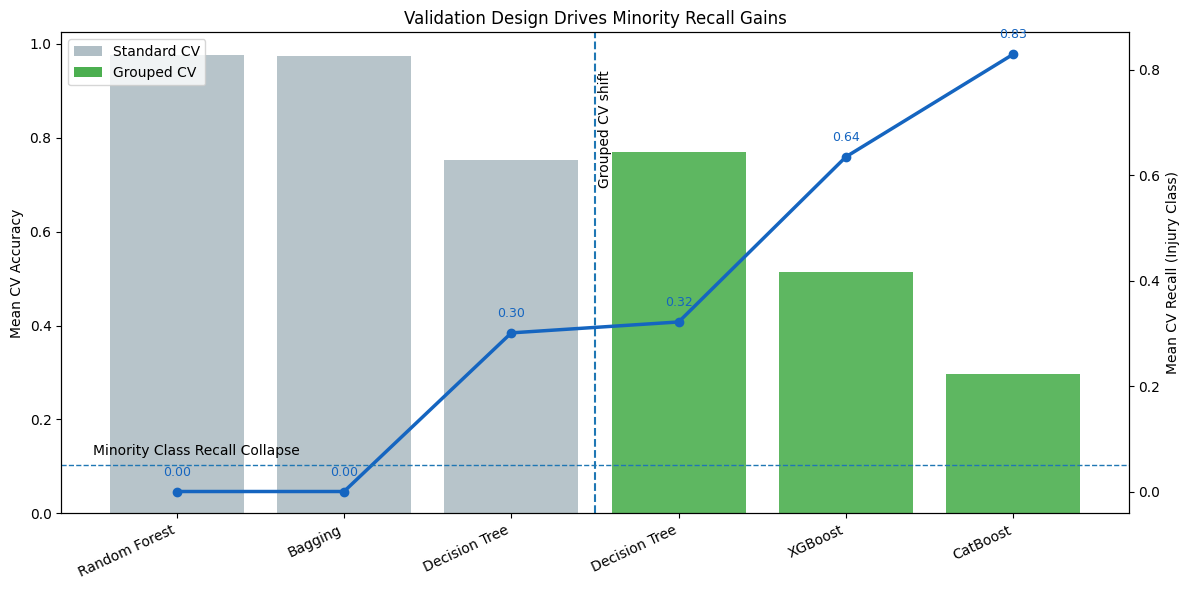

In [ ]:

# --- Clean model names only ---
plot_df["label"] = plot_df["model"].replace({
    "RandomForestClassifier": "Random Forest",
    "BaggingClassifier": "Bagging",
    "XGBClassifier": "XGBoost",
    "CatBoostClassifier": "CatBoost",
    "DecisionTreeClassifier": "Decision Tree"
})

# --- Explicit grouping flag ---
grouped_runs = [
    "XGBoost - Grouped CV",
    "DT Classifier - Grouped CV by Game",
    "CatBoost Tuned"
]

plot_df["grouped_cv"] = plot_df["run_comment"].isin(grouped_runs)

# --- Sort for narrative (low → high recall) ---
plot_df = plot_df.sort_values("mean_cv_recall").reset_index(drop=True)

x = np.arange(len(plot_df))

# --- Colors ---
bar_colors = plot_df["grouped_cv"].map({
    True: "#4CAF50",   # grouped = green
    False: "#B0BEC5"   # standard = muted gray
})

line_color = "#1565C0"  # strong blue for recall

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Bars (accuracy) ---
ax1.bar(
    x,
    plot_df["mean_cv_accuracy"],
    color=bar_colors,
    alpha=0.9
)

ax1.set_ylabel("Mean CV Accuracy")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["label"], rotation=25, ha="right")

# --- Recall line ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["mean_cv_recall"],
    marker="o",
    linewidth=2.5,
    color=line_color
)

ax2.set_ylabel("Mean CV Recall (Injury Class)")

# --- Annotate recall values ---
for i, val in enumerate(plot_df["mean_cv_recall"]):
    ax2.text(i, val + 0.03, f"{val:.2f}", ha='center', fontsize=9, color=line_color)

# --- Majority-class collapse line ---
ax2.axhline(0.05, linestyle="--", linewidth=1)
ax2.text(len(plot_df)-6.5, 0.07, "Minority Class Recall Collapse", fontsize=10)

# --- Vertical separator between DT runs ---
dt_indices = plot_df[plot_df["label"] == "Decision Tree"].index.tolist()

if len(dt_indices) >= 2:
    split_x = (dt_indices[0] + dt_indices[1]) / 2
    ax1.axvline(split_x, linestyle="--", linewidth=1.5)
    ax1.text(split_x + 0.02, 0.7, "Grouped CV shift", rotation=90, fontsize=10)

# --- Legend proxy (since colors encode meaning) ---
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#B0BEC5", label="Standard CV"),
    Patch(facecolor="#4CAF50", label="Grouped CV"),
]

ax1.legend(handles=legend_elements, loc="upper left")

plt.title("Validation Design Drives Minority Recall Gains")
plt.tight_layout()
plt.show()

In [114]:
combined_results

,model,model_params,mean_cv_accuracy,std_cv_accuracy,mean_cv_balanced_accuracy,std_cv_balanced_accuracy,mean_cv_recall,std_cv_recall,train_accuracy,test_accuracy,balanced_train_accuracy,balanced_test_accuracy,train_recall,test_recall,run_comment
0,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.739420,0.073812,0.550876,0.036933,0.352531,0.105049,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,Final tuned Decision Tree
1,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.739420,0.073812,0.550876,0.036933,0.352531,0.105049,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,Final tuned Decision Tree
2,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.975289,0.000285,0.500000,0.000000,0.000000,0.000000,0.975289,0.976608,0.500000,0.500000,0.000000,0.000,Final tuned Random Forest
3,BaggingClassifier,"{'bootstrap': True, 'bootstrap_features': Fals...",0.974762,0.000746,0.499730,0.000344,0.000000,0.000000,0.997222,0.976608,0.949554,0.500000,0.899408,0.000,Final Bagging Trees (Collapsed Recall)
4,DecisionTreeClassifier,"{'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 2...",0.748157,0.067671,0.526025,0.021833,0.291514,0.114014,0.743384,0.748538,0.646402,0.493039,0.544379,0.225,DT Classifier - Grouped CV by Game
5,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.635895,0.078299,0.612752,0.043797,0.587734,0.156832,0.669250,0.651462,0.720857,0.528743,0.775148,0.400,XGBoost - Grouped CV
6,CatBoostClassifier,"{'iterations': 500, 'learning_rate': 0.03, 'de...",0.972238,0.006182,0.498557,0.000580,0.000000,0.000000,0.985963,0.973684,0.730394,0.498503,0.461538,0.000,CatBoost Tuned - Grouped CV
